In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyleoclim.utils.wavelet import cwt_coherence
import scipy.signal as ss
from scipy.interpolate import PchipInterpolator, interp1d
from sklearn.preprocessing import (
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
)
from pipeline import divide_data

In [2]:
# Load data
df_raw = pd.read_excel("data/nc0304_pilot_data_truncated.xlsx")
df = divide_data(df_raw, 1200, 2000)

In [3]:
def plot_cos_angles_by_index(t_rs, p1_unwrapped_rs, p2_unwrapped_rs, i_start, i_end):
    """
    Plot cos(p1) and cos(p2) vs time over an index slice [i_start:i_end).

    Args:
        t_rs, p1_unwrapped_rs, p2_unwrapped_rs: 1D arrays of same length
        i_start, i_end: int indices (Python slicing; end is exclusive)
        figsize: tuple

    Returns:
        (fig, ax)
    """
    n = min(len(t_rs), len(p1_unwrapped_rs), len(p2_unwrapped_rs))

    X = np.column_stack([p1_unwrapped_rs, p2_unwrapped_rs])  # (n, 2)
    scaler = StandardScaler()
    X_scaled = X #scaler.fit_transform(X)
    

    p1_scaled = X_scaled[:, 0]
    p2_scaled = X_scaled[:, 1]
    # p1_scaled = scaler.fit(p1_unwrapped_rs)
    # p2_scaled = scaler.fit(p2_unwrapped_rs)
    i_start = int(i_start)
    i_end = int(i_end)

    # clip to bounds and ensure valid slice
    i_start = max(0, min(i_start, n))
    i_end = max(i_start, min(i_end, n))

    tt = t_rs[i_start:i_end]
    # y1 = np.cos(p1_scaled[i_start:i_end])
    # y2 = np.cos(p2_scaled[i_start:i_end])
    y1 = p1_scaled[i_start:i_end]
    y2 = p2_scaled[i_start:i_end]
    

    fig, ax = plt.subplots(1, 1) #figsize=figsize)
    ax.plot(tt, y1, label="time vs p1 angle")
    ax.plot(tt, y2, label="time vs p2 angle")
    # ax.legend(fontsize=12)
    ax.set_xlabel("time", fontsize=10)
    ax.set_ylabel("angle (rad)", fontsize=10)
    ax.grid(True)
    plt.legend()
    plt.show()

    return fig, ax


# Example:
# plot_cos_angles_by_index(t_rs, p1_unwrapped_rs, p2_unwrapped_rs, i_start=8000, i_end=9000)

In [4]:
####INTERPOLATE data####
time_col = "time"
angle_cols = ["p1_unwrapped", "p2_unwrapped"]
current_cols = ["i1", "i2"]

# 1) sort + collapse duplicate timestamps
df = df.sort_values(time_col)
df = df.groupby(time_col, as_index=False).mean()

# extract columns
z = df["time"].to_numpy() 
p1_angle = df["angle_p1"].to_numpy()
p2_angle = df["angle_p2"].to_numpy()
i1 = df["i1"].to_numpy()
i2 = df["i2"].to_numpy()
p1 = df["p1"].to_numpy()
p2 = df["p2"].to_numpy()

# 2) unwrap
p1_unwrapped = np.unwrap(p1_angle-np.pi)#+np.pi 
p2_unwrapped = np.unwrap(p2_angle-np.pi)#+np.pi

#add unwrapped columns to df
df["p1_unwrapped"] = p1_unwrapped
df["p2_unwrapped"] = p2_unwrapped

# 3) make uniform 0.001s grid
dt_target = 0.001
t_new = np.arange(z.min(), z.max() + dt_target/2, dt_target)

# 4) interpolate angles (PCHIP is shape-preserving)
out = {time_col: t_new}

for c in angle_cols:
    y = df[c].to_numpy()
    out[c] = PchipInterpolator(z, y)(t_new)

# 5) interpolate currents (linear)
for c in current_cols:
    y = df[c].to_numpy()
    out[c] = interp1d(z, y, kind="linear", bounds_error=False, fill_value="extrapolate")(t_new)

df_rs = pd.DataFrame(out)

# extract resampled columns
t_rs = df_rs[time_col].to_numpy()
p1_unwrapped_rs = df_rs["p1_unwrapped"].to_numpy()
p2_unwrapped_rs = df_rs["p2_unwrapped"].to_numpy()
i1_rs = df_rs["i1"].to_numpy()
i2_rs = df_rs["i2"].to_numpy()

# 6) compute torque + velocity
df_rs["torque1"] = df_rs["i1"] * 0.011
df_rs["torque2"] = df_rs["i2"] * 0.011

df_rs["omega1"] = np.gradient(df_rs["p1_unwrapped"].to_numpy(), dt_target)
df_rs["omega2"] = np.gradient(df_rs["p2_unwrapped"].to_numpy(), dt_target)


In [5]:
"""
#Check if t is uniform
dt = np.diff(t_rs)
print(dt.min(), dt.max(), dt.mean(), dt.std()) #Diagnose whether t is uniform

#NOTE: t not uniform
"""

'\n#Check if t is uniform\ndt = np.diff(t_rs)\nprint(dt.min(), dt.max(), dt.mean(), dt.std()) #Diagnose whether t is uniform\n\n#NOTE: t not uniform\n'

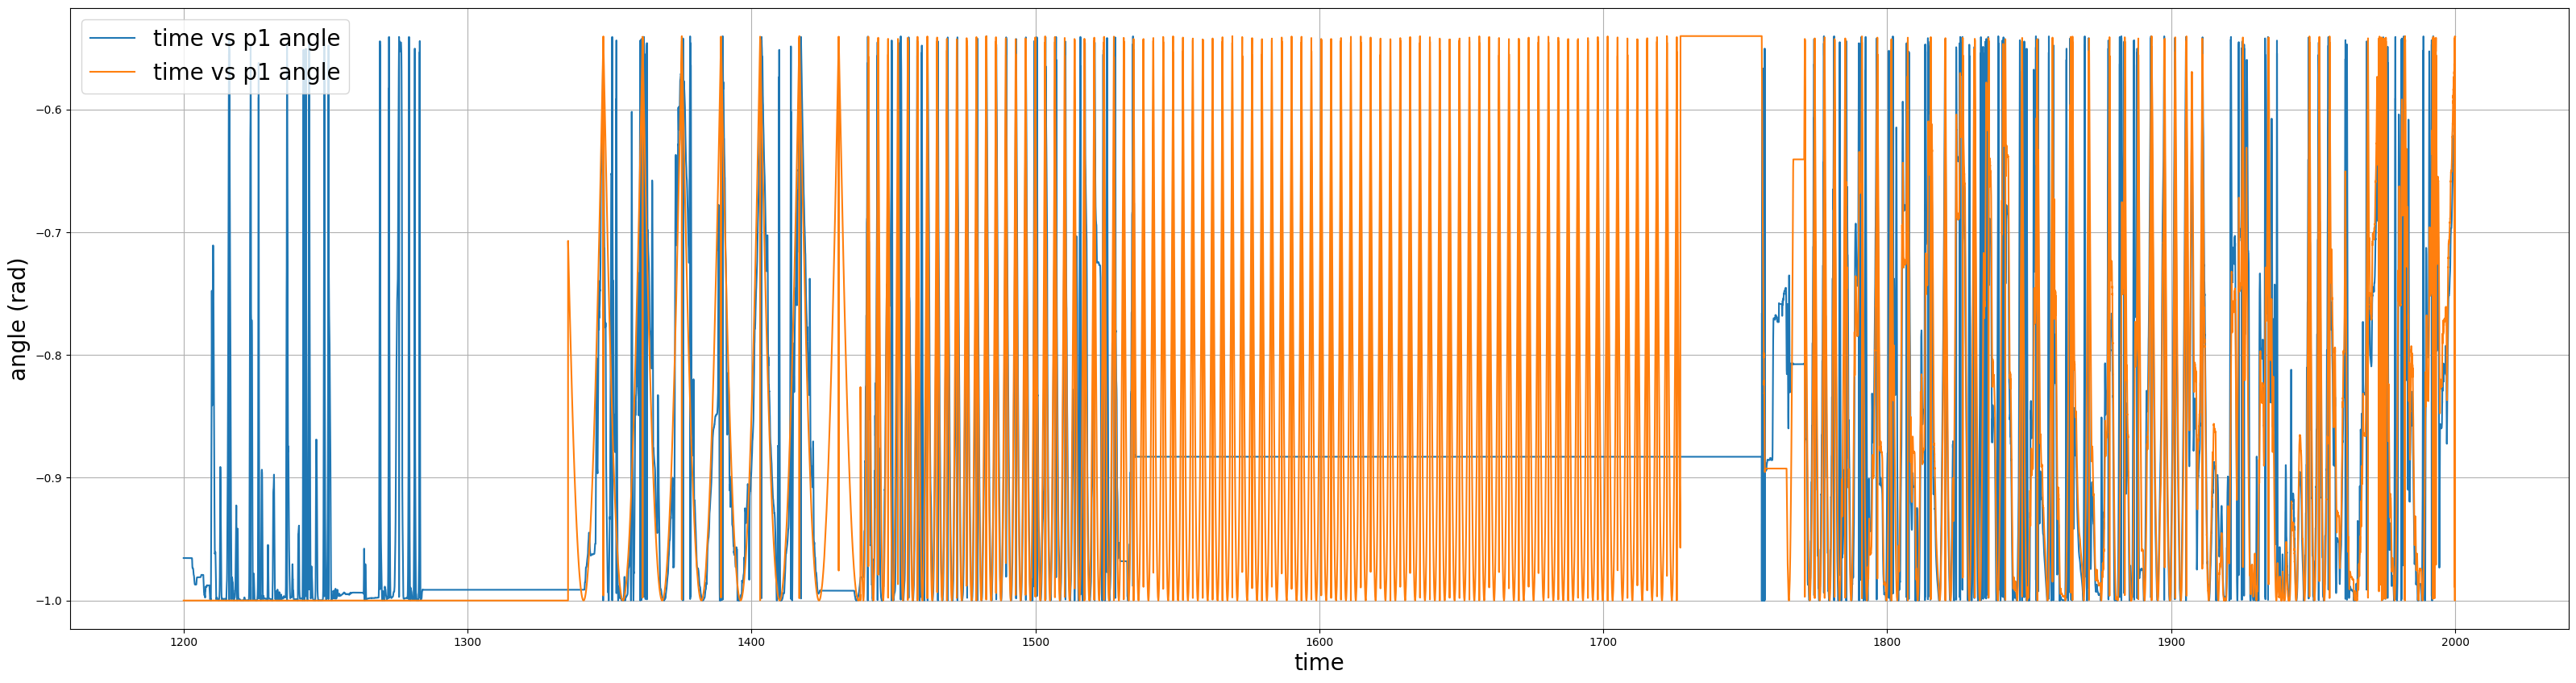

In [6]:
fig, axs = plt.subplots(1, 1, figsize=(40, 10))
axs.plot(t_rs, np.cos(p1_unwrapped_rs), label="time vs p1 angle")
axs.plot(t_rs, np.cos(p2_unwrapped_rs), label="time vs p1 angle")
plt.legend(fontsize=20)
plt.xlabel("time", fontsize=20)
plt.ylabel("angle (rad)", fontsize=20)
plt.grid(True)
# plt.xticks(np.arange(0, 4000, 100))

In [7]:
# 1. unwrap
theta1 = p1_unwrapped_rs
theta2 = p2_unwrapped_rs

# 2. compute angular velocity
dt = np.mean(np.diff(t_rs))   # seconds
omega1 = np.gradient(theta1, dt)
omega2 = np.gradient(theta2, dt)

# 3. optional but recommended smoothing
from scipy.signal import savgol_filter
omega1 = savgol_filter(omega1, window_length=11, polyorder=3)
omega2 = savgol_filter(omega2, window_length=11, polyorder=3)

In [8]:
tau1 = i1_rs * 0.011  # seconds
# power1 = tau1 * omega1

tau2 = i2_rs * 0.011  # seconds
# power2 = tau2 * omega2

In [9]:
print("c =", c, "type:", type(c))

c = i2 type: <class 'str'>


Text(0.5, 1.0, 'Angular Velocity vs Time')

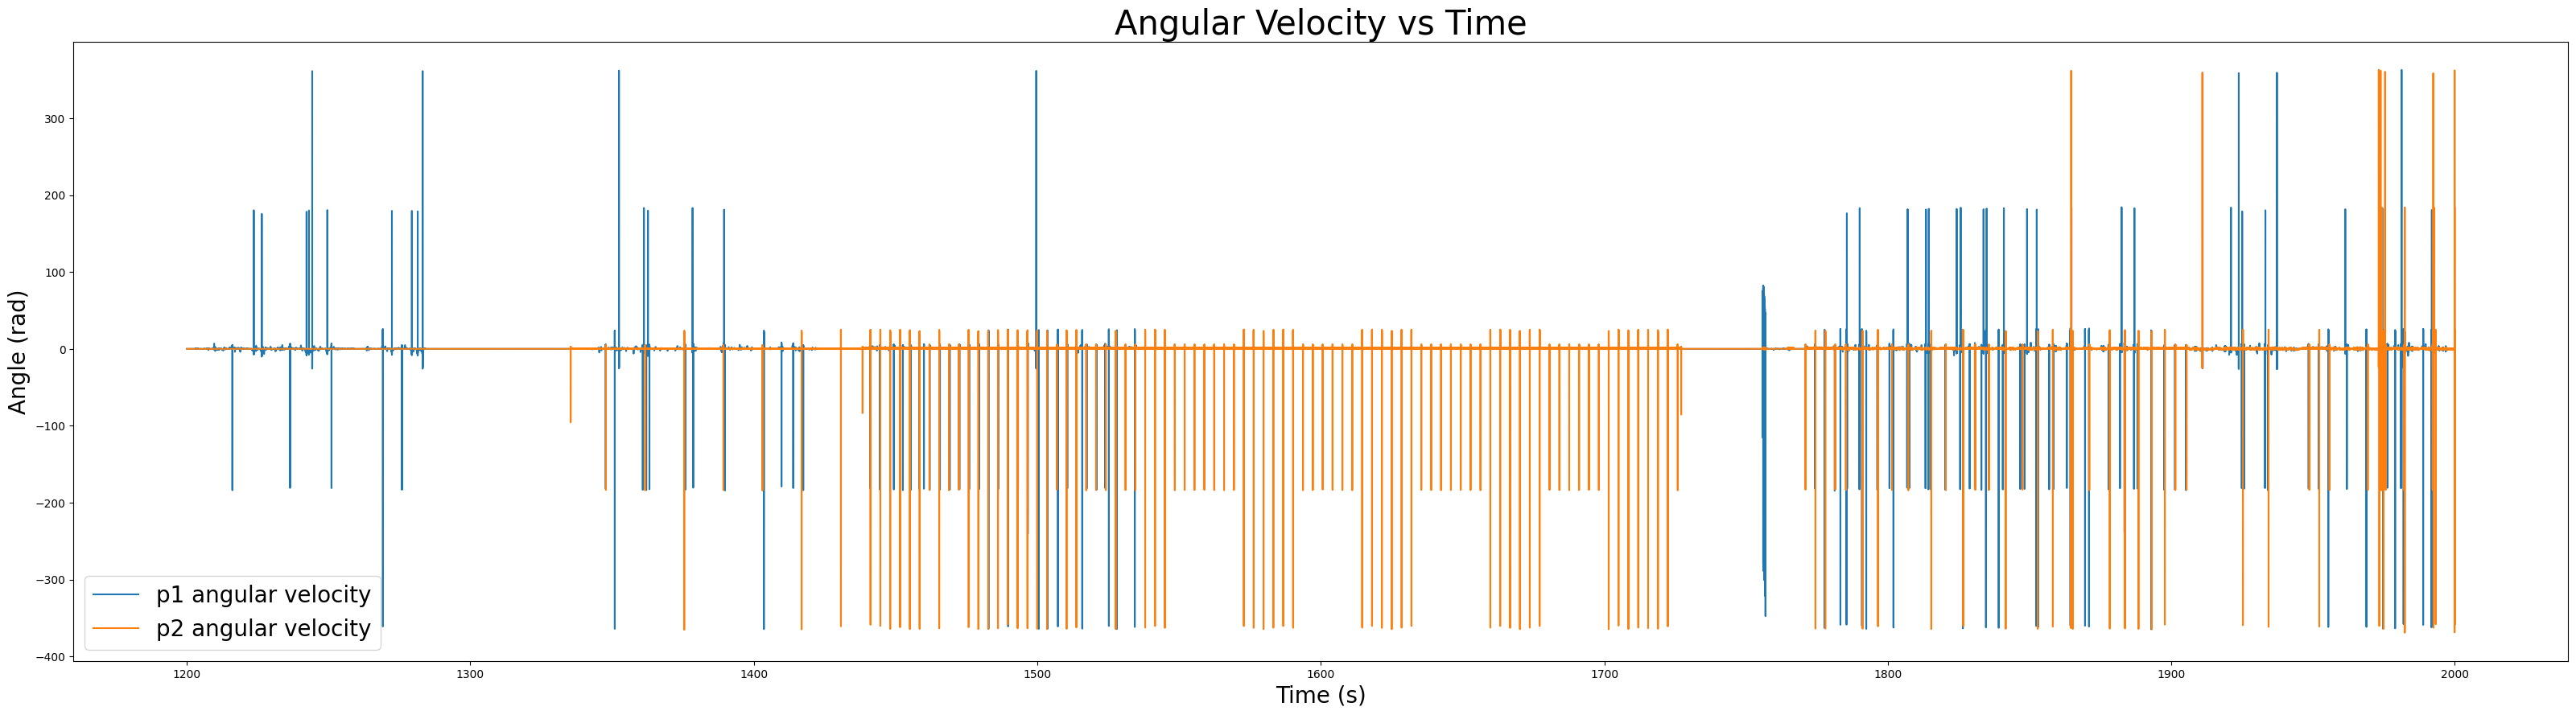

In [10]:
fig, axs = plt.subplots(1, 1, figsize=(40, 10))
# plt.plot(t_rs, omega1, label="p1 angular velocity")
axs.plot(t_rs, omega1, label="p1 angular velocity")
axs.plot(t_rs, omega2, label="p2 angular velocity")
# plt.plot(t_rs, omega2, label="p2 angular velocity", alpha=0.7)
plt.legend(fontsize=20)
plt.xlabel("Time (s)", fontsize=20)
plt.ylabel("Angle (rad)",fontsize=20)
plt.title("Angular Velocity vs Time", fontsize=30)
# plt.tight_layout()

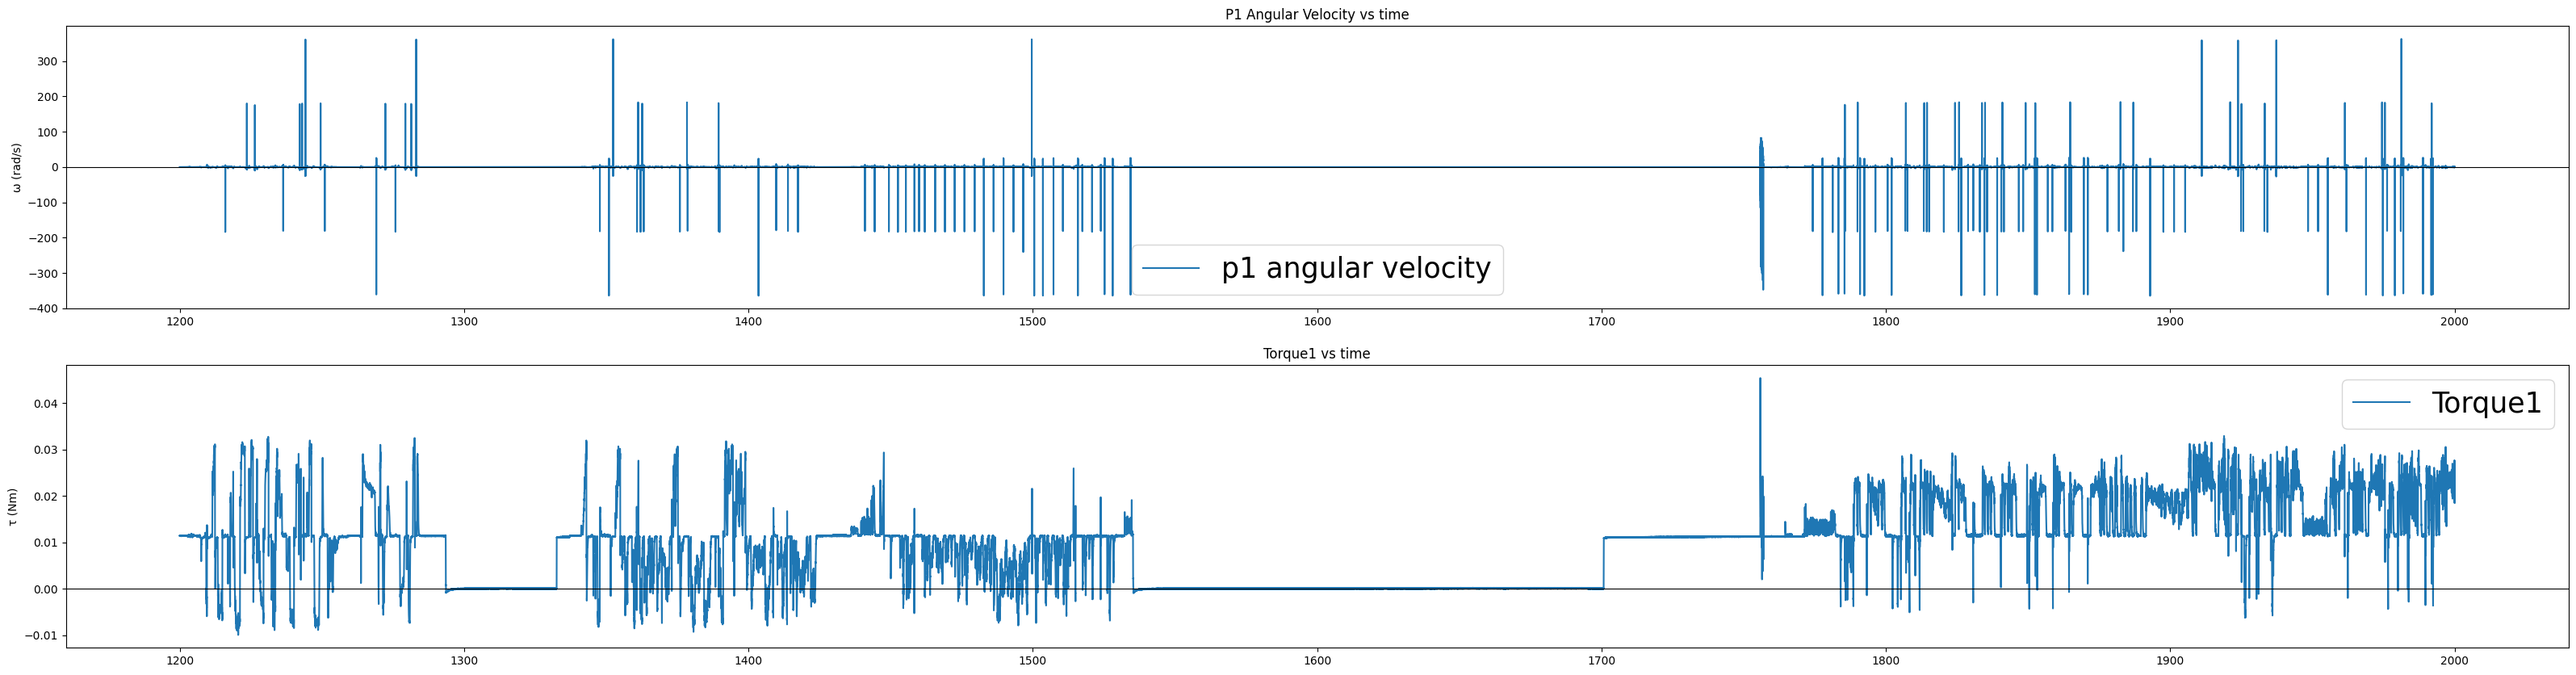

In [11]:
# fig, ax = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
fig, ax = plt.subplots(2, 1, figsize=(40, 10))
ax[0].plot(t_rs, omega1, label="p1 angular velocity")
ax[0].axhline(0, color="k", lw=0.8)
ax[0].set_ylabel("ω (rad/s)")
ax[0].set_title("P1 Angular Velocity vs time")
ax[0].legend(fontsize=25)

ax[1].plot(t_rs, tau1, label="Torque1")
ax[1].axhline(0, color="k", lw=0.8)
ax[1].set_ylabel("τ (Nm)")
ax[1].set_title("Torque1 vs time")
ax[1].legend(fontsize=25)

# ax[2].plot(t_rs, power1)
# ax[2].axhline(0, color="k", lw=0.8)
# ax[2].set_ylabel("P = τ·ω (W)")
# ax[2].set_xlabel("Time (s)")
plt.show()

In [12]:
def relative_phase_dis(x1, x2, t):
    # Calculations:
    # 1. Compute continuous wavelet transform (CWT)
    # 2. Compute the cross-wavelet transform (WTC)
    # 3. Extract the relative phase time-series
    # 4. Restrict to the movement-relevant frequency band (1HZ?)
    # TODO: generate plot to sample smaller time windows and extrapolate data to plot mean and standard deviation over whole time window

    """
    def cwt_coherence(y1, t1, y2, t2, freq=None, freq_method='log',freq_kwargs={},
                    scale = None, detrend=False,sg_kwargs={}, pad = False,
                    standardize = True, gaussianize=False, tau = None, Neff_threshold=3,
                    mother='MORLET',param=None, smooth_factor=0.25):
    Returns the wavelet transform coherency of two time series using the CWT.
    """
    # 1. Wavelet coherence
    res = cwt_coherence(x1, t, x2, t, standardize=False, freq_method='log')
    # print("cwt_coherence: ", res)
    
    phi  = res.xw_phase          # (time, freq)
    R2   = res.xw_coherence      # (time, freq)
    freq = res.freq

    # Example band for cos(t) when t is radians:
    band = (freq >= 0) & (freq <= 100)

    w = R2[:, band]
    z = np.exp(1j * phi[:, band])

    zbar = np.sum(w * z, axis=1) / np.sum(w, axis=1)
    phi_t = np.angle(zbar)           # wrapped (-pi, pi]
    # lock_t = np.abs(zbar)            # 0..1 reliability

    """    # 2. Restrict to <= 100 Hz (movement-relevant band)
    low = freq <= (1.0)* 0 + 100
    phase_low = phase[:, low]  # (ntime, n_low_freq)

    # 3. Circular mean across frequencies for each time point
    #    → relative phase time series φ(t)
    complex_phase = np.exp(1j * phase_low)  # (ntime, n_low_freq)
    mean_complex = complex_phase.mean(axis=1)  # average over freq
    phi_t = np.angle(mean_complex)  # (ntime,)"""

    # 4. Build PDF over phase
    bins = np.linspace(-np.pi, np.pi, 73)  # e.g., 5° bins
    hist, edges = np.histogram(phi_t, bins=bins, density=True)
    centers = 0.5 * (edges[:-1] + edges[1:])

    return centers, hist, phi_t


def circular_stats(angles):
    """
    Compute circular mean and circular std for angles in radians.
    """
    angles = np.asarray(angles)
    sin_mean = np.mean(np.sin(angles))
    cos_mean = np.mean(np.cos(angles))

    mean_angle = np.arctan2(sin_mean, cos_mean)

    R = np.sqrt(sin_mean**2 + cos_mean**2)
    R = np.clip(R, 1e-8, 1.0)             # avoid log(0)
    circ_std = np.sqrt(-2 * np.log(R))    # circular std in radians

    return mean_angle, circ_std


# def split_phase_into_windows(t, phi_t, window_size):
#     #TODO: split data into time window and calculate the cwt of that time window. 
#     #TODO: maybe unwrap phi after cwt
#     """
#     Split phase time series into non-overlapping windows and
#     compute circular stats for each window.

#     Parameters
#     ----------
#     t : np.ndarray
#         Time array in seconds.
#     phi_t : np.ndarray
#         Relative phase array (radians), same length as t.
#     window_size : float
#         Window length in seconds (e.g., 2.0, 5.0).

#     Returns
#     -------
#     windows : list of dict
#         Each dict has:
#             'start', 'end', 'center_time',
#             'mean_phase', 'std_phase',
#             't', 'phase'
#     """
#     t = np.asarray(t)
#     phi_t = np.asarray(phi_t)

#     if len(t) != len(phi_t):
#         raise ValueError("t and phi_t must have same length")

#     windows = []
#     start_time = float(t[0])
#     end_time   = float(t[-1])

#     current_start = start_time
#     while current_start < end_time:
#         current_end = current_start + window_size
#         # non-overlapping windows aligned to dataset start
#         mask = (t >= current_start) & (t < current_end)

#         if np.any(mask):
#             t_win = t[mask]
#             phi_win = phi_t[mask]
            
            

#             mean_phase, std_phase = circular_stats(phi_win)

#             windows.append({
#                 "start": current_start,
#                 "end": current_end,
#                 "center_time": 0.5 * (current_start + current_end),
#                 "mean_phase": mean_phase,
#                 "std_phase": std_phase,
#                 "t": t_win,
#                 "phase": phi_win,
#             })

#         current_start = current_end

#     return windows



In [13]:
def split_phase_into_windows(x1, x2, t, window_size,
                                 freq_band=(0, 100)):
    """
    Windowed CWT coherence phase analysis.

    Parameters
    ----------
    x1, x2 : np.ndarray
        Input signals.
    t : np.ndarray
        Time array (seconds).
    window_size : float
        Window length (seconds).
    freq_band : tuple
        (fmin, fmax)

    Returns
    -------
    windows : list of dict
        Each dict has:
            'start', 'end', 'center_time',
            'mean_phase', 'std_phase',
            'phi_t', 't'
    """

    t = np.asarray(t)
    x1 = np.asarray(x1)
    x2 = np.asarray(x2)

    if not (len(t) == len(x1) == len(x2)):
        raise ValueError("x1, x2, t must have same length")

    windows = []

    start_time = float(t[0])
    end_time   = float(t[-1])

    current_start = start_time
    while current_start < end_time:

        current_end = current_start + window_size
        mask = (t >= current_start) & (t < current_end)

        if np.sum(mask) > 10:   # avoid tiny windows

            t_win  = t[mask]
            x1_win = x1[mask]
            x2_win = x2[mask]

            # ---- CWT coherence ----
            res = cwt_coherence(
                x1_win, t_win,
                x2_win, t_win,
                standardize=False,
                freq_method='log'
            )

            phi  = res.xw_phase      # (time, freq)
            R2   = res.xw_coherence  # (time, freq)
            freq = res.freq

            # # ---- Restrict frequency band ----
            band = (freq >= freq_band[0]) & (freq <= freq_band[1])

            w = R2[:, band]
            z = np.exp(1j * phi[:, band])

            # ---- Weighted circular mean across freq ----
            zbar = np.sum(w * z, axis=1) / np.sum(w, axis=1)
            phi_t = np.angle(zbar)

            # ---- Unwrap AFTER CWT ----
            phi_t = np.unwrap(phi_t)

            # ---- Circular stats ----
            mean_phase, std_phase = circular_stats(phi_t)

            windows.append({
                "start": current_start,
                "end": current_end,
                "center_time": 0.5 * (current_start + current_end),
                "mean_phase": mean_phase,
                "std_phase": std_phase,
                "phi_t": phi_t,
                "t": t_win
            })

        current_start = current_end

    return windows

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def analyze_relative_phase_windowed(theta1, theta2, t_rs, start_time, end_time, window_size=0.1):
    """
    Slice [start_time : start_time+step] from signals, compute relative phase PDF,
    then compute windowed mean/std of phase vs time and plot both.

    Returns:
        centers, pdf, phi_t, window_stats
    """
    # indices
    t1 = int(start_time)
    t2 = int(end_time)

    # clip to array bounds
    n = min(len(theta1), len(theta2), len(t_rs))
    t1 = max(0, min(t1, n))
    t2 = max(t1, min(t2, n))

    # slice
    p1 = theta1[t1:t2]
    p2 = theta2[t1:t2]
    t  = t_rs[t1:t2]

    # compute phase + PDF
    centers, pdf, phi_t = relative_phase_dis(p1, p2, t)

    plt.figure()
    plt.plot(centers, pdf)
    plt.xlabel("Relative phase (rad)")
    plt.ylabel("PDF")
    plt.title(f"t1={t1}, t2={t2}")
    plt.show()

    # window stats
    window_stats = split_phase_into_windows(p1, p2, t, window_size=window_size)
    # for w in window_stats:
        # print(
        #     f"Window {w['start']}–{w['end']} s: "
        #     f"mean phase={w['mean_phase']:.2f} rad, "
        #     f"std={w['std_phase']:.2f} rad"
        # )

    centers_t = np.array([w["center_time"] for w in window_stats])
    means     = np.array([w["mean_phase"]  for w in window_stats])
    stds      = np.array([w["std_phase"]   for w in window_stats])

    plt.figure()
    plt.errorbar(centers_t, means, yerr=stds, fmt="o", capsize=4)
    plt.xlabel("Window center time (s)")
    plt.ylim(-np.pi*1.05, np.pi*1.05)
    plt.ylabel("Relative phase (rad)")
    plt.title(f"Relative phase per {window_size}s window (mean ± std)")
    plt.legend()
    plt.grid(True)
    plt.show()
    
    plot_cos_angles_by_index(t_rs, theta1, theta2, t1, t2)
    return centers, pdf, phi_t, window_stats


# Example:
# centers, pdf, phi_t, window_stats = analyze_relative_phase_windowed(
#     theta1, theta2, t_rs, start_time=8000, step=1000, window_size=0.1
# )

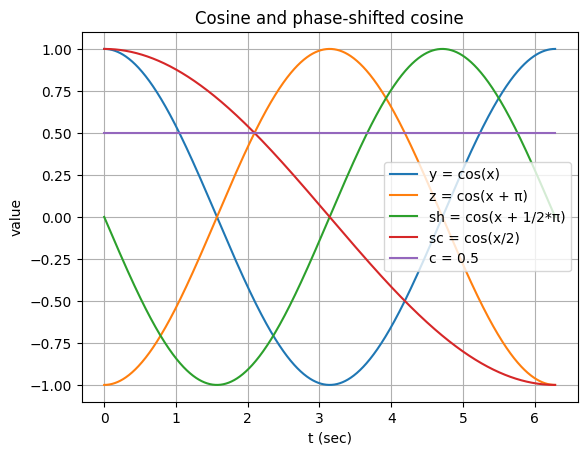

In [15]:
# x domain (radians)
x = np.linspace(0, 2*np.pi, 1000)

# signals
y = np.cos(x)              # y = cos(x)
z = np.cos(x + np.pi)      # z = cos(x + pi) = -cos(x)
sh = np.cos(x +1/2*np.pi) 
sc = np.cos(x/2) 
c = 0.5
c_sig = np.full_like(x, c)

# plot
plt.figure()
plt.plot(x, y, label="y = cos(x)")
plt.plot(x, z, label="z = cos(x + π)")
plt.plot(x, sh, label="sh = cos(x + 1/2*π)")
plt.plot(x, sc, label="sc = cos(x/2)")
plt.plot(x, c_sig, label="c = 0.5")   # constant line
plt.xlabel("t (sec)")
plt.ylabel("value")
plt.title("Cosine and phase-shifted cosine")
plt.grid(True)
plt.legend()
plt.show()

Setting freq=[2.         2.2335146  2.49429374]...[400.915091   447.72485468 500.00000001], nfreq=51
Setting freq=[2.00400802 2.23790097 2.49909218]...[400.9471976  447.74278197 500.00000001], nfreq=51
Setting freq=[2.00400802 2.23790097 2.49909218]...[400.9471976  447.74278197 500.00000001], nfreq=51
Setting freq=[2.00400802 2.23790097 2.49909218]...[400.9471976  447.74278197 500.00000001], nfreq=51
Setting freq=[2.00400802 2.23790097 2.49909218]...[400.9471976  447.74278197 500.00000001], nfreq=51
Setting freq=[2.00400802 2.23790097 2.49909218]...[400.9471976  447.74278197 500.00000001], nfreq=51
Setting freq=[2.00400802 2.23790097 2.49909218]...[400.9471976  447.74278197 500.00000001], nfreq=51
Setting freq=[2.00400802 2.23790097 2.49909218]...[400.9471976  447.74278197 500.00000001], nfreq=51
Setting freq=[2.00400802 2.23790097 2.49909218]...[400.9471976  447.74278197 500.00000001], nfreq=51
Setting freq=[2.00400802 2.23790097 2.49909218]...[400.9471976  447.74278197 500.00000001],

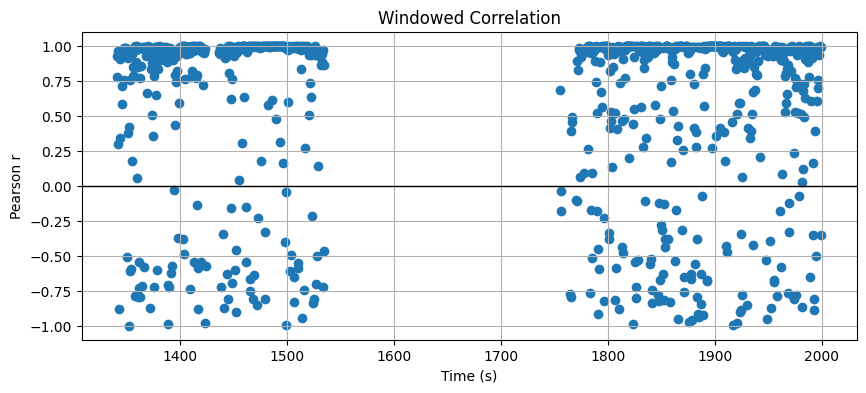

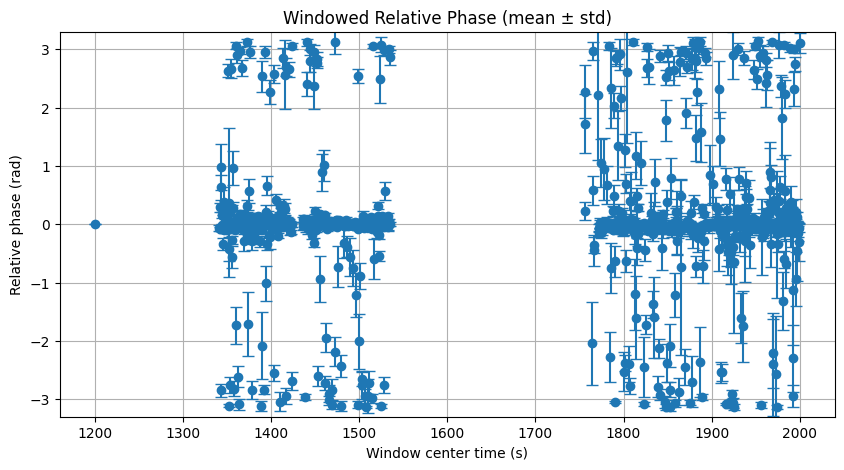

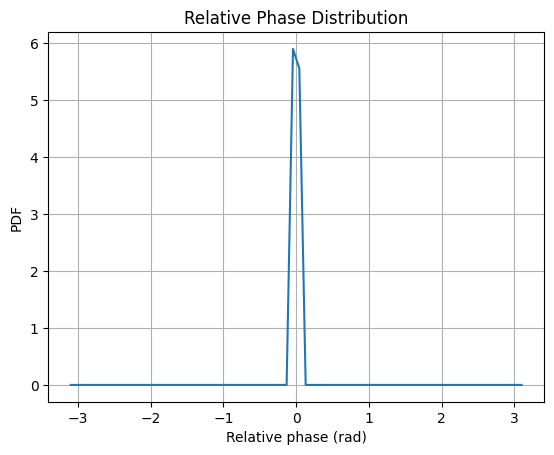

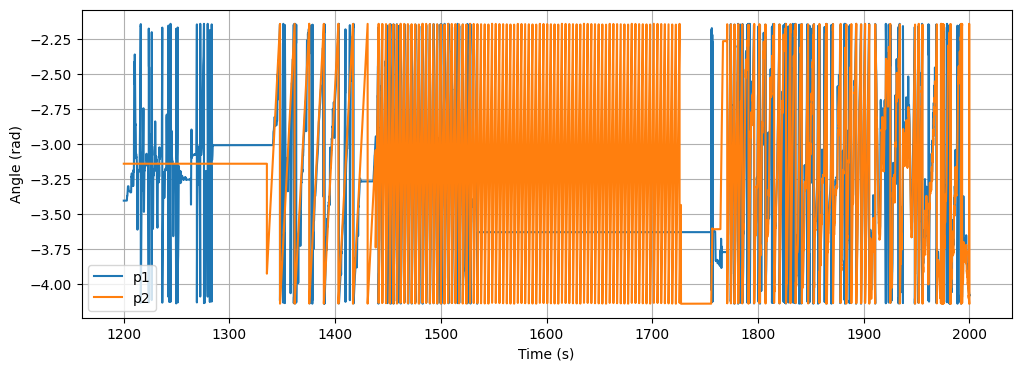

In [16]:
from pipeline import windowed_phase_analysis, plot_windowed_phase, plot_windowed_correlation, plot_angles

# Example:
windows = windowed_phase_analysis(theta1, theta2, t_rs, window_size=0.5)
plot_windowed_correlation(windows)
plot_windowed_phase(windows)
plot_angles(t_rs, theta1, theta2)
# windowed_phase_analysis(z, sh, x, window_size=0.5)
# windowed_phase_analysis(z, sc, x, window_size=0.5)

Setting freq=[0.15915494 0.16935791 0.18021496]...[70.20772725 74.70854345 79.49789407], nfreq=101


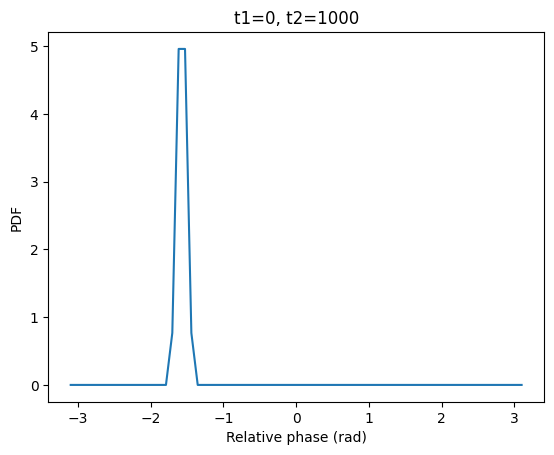

Setting freq=[2.01260491 3.18664119 5.04554173]...[31.71073806 50.20893243 79.49789407], nfreq=9
Setting freq=[2.03840754 3.44021798 5.80605178]...[27.91037917 47.10431367 79.49789407], nfreq=8
Setting freq=[2.01260491 3.18664119 5.04554173]...[31.71073806 50.20893243 79.49789407], nfreq=9
Setting freq=[2.03840754 3.44021798 5.80605178]...[27.91037917 47.10431367 79.49789407], nfreq=8
Setting freq=[2.01260491 3.18664119 5.04554173]...[31.71073806 50.20893243 79.49789407], nfreq=9
Setting freq=[2.03840754 3.44021798 5.80605178]...[27.91037917 47.10431367 79.49789407], nfreq=8
Setting freq=[2.01260491 3.18664119 5.04554173]...[31.71073806 50.20893243 79.49789407], nfreq=9
Setting freq=[2.03840754 3.44021798 5.80605178]...[27.91037917 47.10431367 79.49789407], nfreq=8
Setting freq=[2.01260491 3.18664119 5.04554173]...[31.71073806 50.20893243 79.49789407], nfreq=9
Setting freq=[2.03840754 3.44021798 5.80605178]...[27.91037917 47.10431367 79.49789407], nfreq=8
Setting freq=[2.01260491 3.186

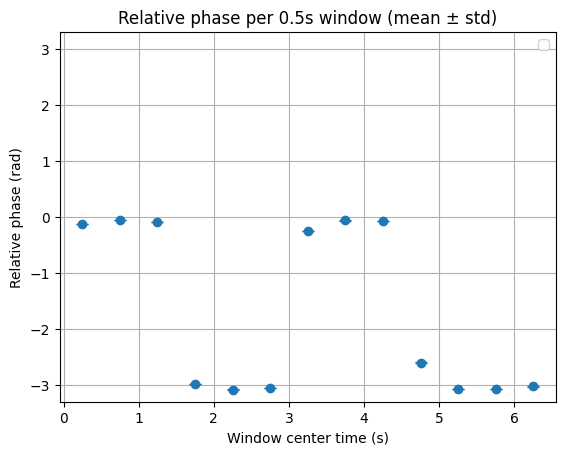

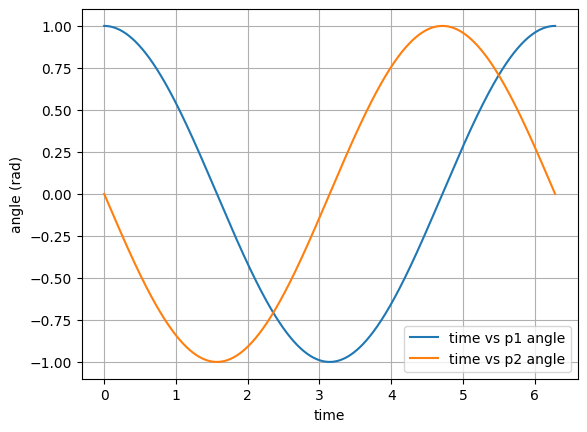

Setting freq=[0.15915494 0.16935791 0.18021496]...[70.20772725 74.70854345 79.49789407], nfreq=101


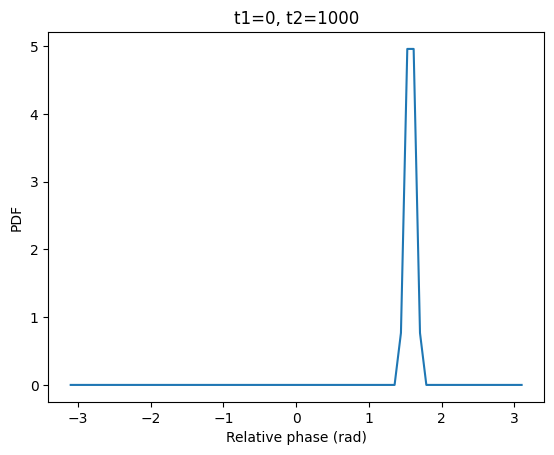

Setting freq=[2.01260491 3.18664119 5.04554173]...[31.71073806 50.20893243 79.49789407], nfreq=9
Setting freq=[2.03840754 3.44021798 5.80605178]...[27.91037917 47.10431367 79.49789407], nfreq=8
Setting freq=[2.01260491 3.18664119 5.04554173]...[31.71073806 50.20893243 79.49789407], nfreq=9
Setting freq=[2.03840754 3.44021798 5.80605178]...[27.91037917 47.10431367 79.49789407], nfreq=8
Setting freq=[2.01260491 3.18664119 5.04554173]...[31.71073806 50.20893243 79.49789407], nfreq=9
Setting freq=[2.03840754 3.44021798 5.80605178]...[27.91037917 47.10431367 79.49789407], nfreq=8
Setting freq=[2.01260491 3.18664119 5.04554173]...[31.71073806 50.20893243 79.49789407], nfreq=9
Setting freq=[2.03840754 3.44021798 5.80605178]...[27.91037917 47.10431367 79.49789407], nfreq=8
Setting freq=[2.01260491 3.18664119 5.04554173]...[31.71073806 50.20893243 79.49789407], nfreq=9
Setting freq=[2.03840754 3.44021798 5.80605178]...[27.91037917 47.10431367 79.49789407], nfreq=8
Setting freq=[2.01260491 3.186

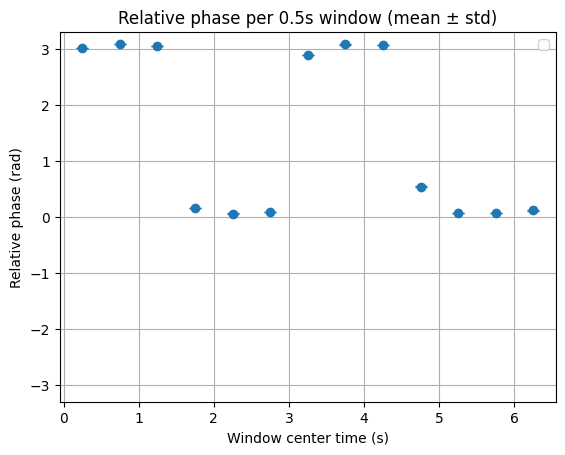

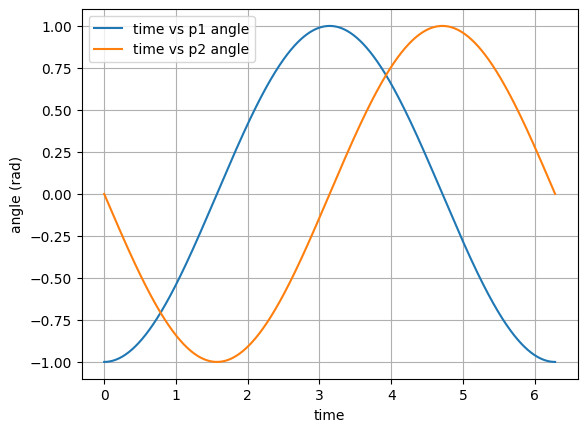

Setting freq=[0.15915494 0.16935791 0.18021496]...[70.20772725 74.70854345 79.49789407], nfreq=101


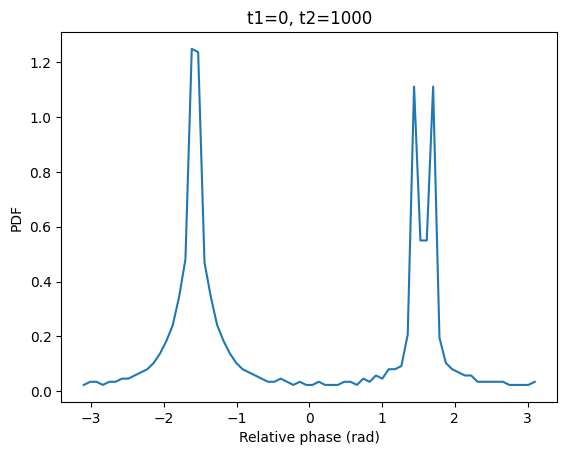

Setting freq=[2.01260491 3.18664119 5.04554173]...[31.71073806 50.20893243 79.49789407], nfreq=9
Setting freq=[2.03840754 3.44021798 5.80605178]...[27.91037917 47.10431367 79.49789407], nfreq=8
Setting freq=[2.01260491 3.18664119 5.04554173]...[31.71073806 50.20893243 79.49789407], nfreq=9
Setting freq=[2.03840754 3.44021798 5.80605178]...[27.91037917 47.10431367 79.49789407], nfreq=8
Setting freq=[2.01260491 3.18664119 5.04554173]...[31.71073806 50.20893243 79.49789407], nfreq=9
Setting freq=[2.03840754 3.44021798 5.80605178]...[27.91037917 47.10431367 79.49789407], nfreq=8
Setting freq=[2.01260491 3.18664119 5.04554173]...[31.71073806 50.20893243 79.49789407], nfreq=9
Setting freq=[2.03840754 3.44021798 5.80605178]...[27.91037917 47.10431367 79.49789407], nfreq=8
Setting freq=[2.01260491 3.18664119 5.04554173]...[31.71073806 50.20893243 79.49789407], nfreq=9
Setting freq=[2.03840754 3.44021798 5.80605178]...[27.91037917 47.10431367 79.49789407], nfreq=8
Setting freq=[2.01260491 3.186

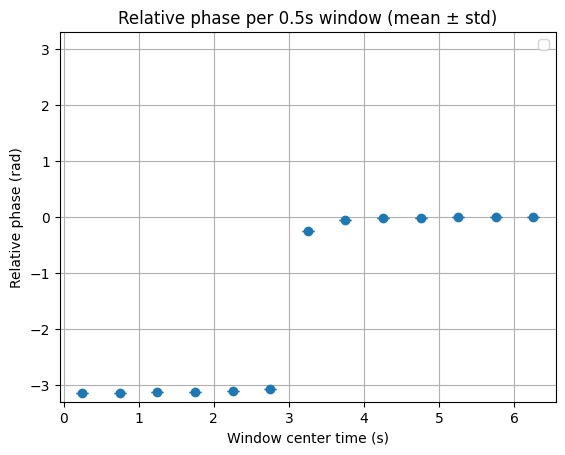

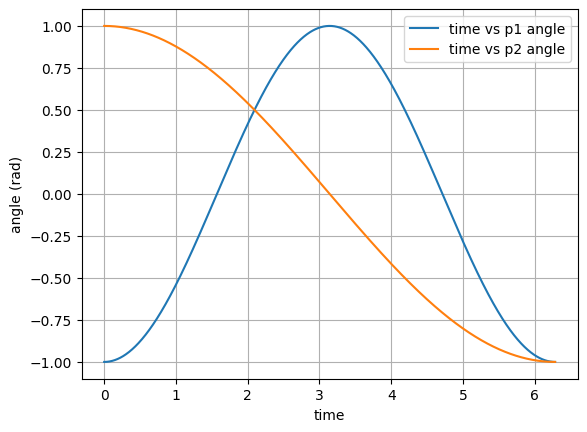

In [17]:
centers, pdf, phi_t, window_stats = analyze_relative_phase_windowed(
    y, sh, x, start_time=0, end_time=len(x), window_size=0.5
)
centers, pdf, phi_t, window_stats = analyze_relative_phase_windowed(
    z, sh, x, start_time=0, end_time=len(x), window_size=0.5
)
centers, pdf, phi_t, window_stats = analyze_relative_phase_windowed(
    z, sc, x, start_time=0, end_time=len(x), window_size=0.5
)

Setting freq=[0.15915494 0.16935791 0.18021496]...[70.20772725 74.70854345 79.49789407], nfreq=101


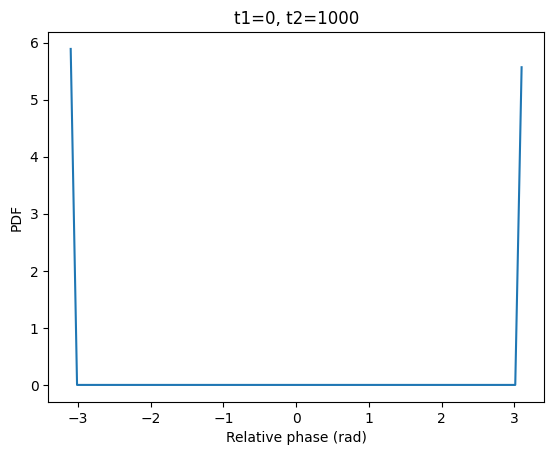

Setting freq=[2.01260491 3.18664119 5.04554173]...[31.71073806 50.20893243 79.49789407], nfreq=9
Setting freq=[2.03840754 3.44021798 5.80605178]...[27.91037917 47.10431367 79.49789407], nfreq=8
Setting freq=[2.01260491 3.18664119 5.04554173]...[31.71073806 50.20893243 79.49789407], nfreq=9
Setting freq=[2.03840754 3.44021798 5.80605178]...[27.91037917 47.10431367 79.49789407], nfreq=8
Setting freq=[2.01260491 3.18664119 5.04554173]...[31.71073806 50.20893243 79.49789407], nfreq=9
Setting freq=[2.03840754 3.44021798 5.80605178]...[27.91037917 47.10431367 79.49789407], nfreq=8
Setting freq=[2.01260491 3.18664119 5.04554173]...[31.71073806 50.20893243 79.49789407], nfreq=9
Setting freq=[2.03840754 3.44021798 5.80605178]...[27.91037917 47.10431367 79.49789407], nfreq=8
Setting freq=[2.01260491 3.18664119 5.04554173]...[31.71073806 50.20893243 79.49789407], nfreq=9
Setting freq=[2.03840754 3.44021798 5.80605178]...[27.91037917 47.10431367 79.49789407], nfreq=8
Setting freq=[2.01260491 3.186

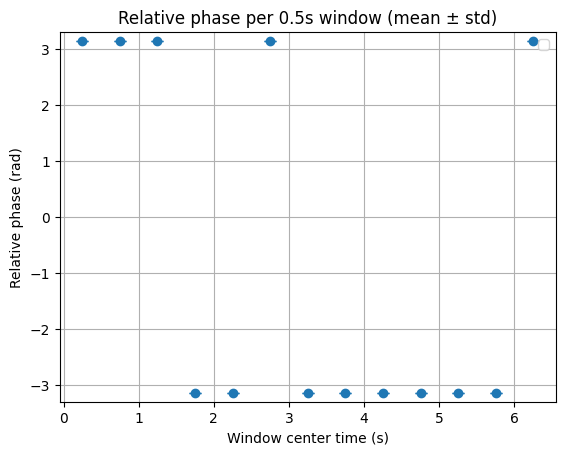

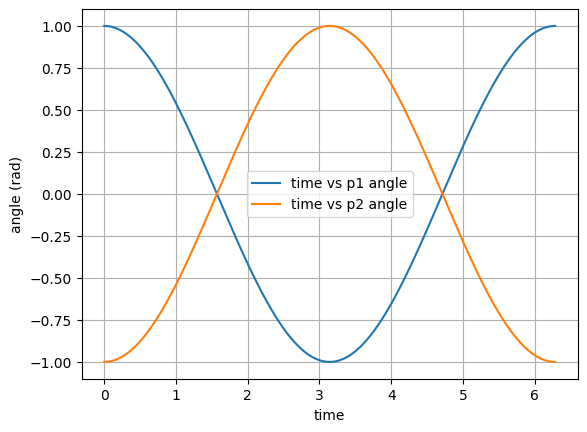

Setting freq=[0.15915494 0.16935791 0.18021496]...[70.20772725 74.70854345 79.49789407], nfreq=101


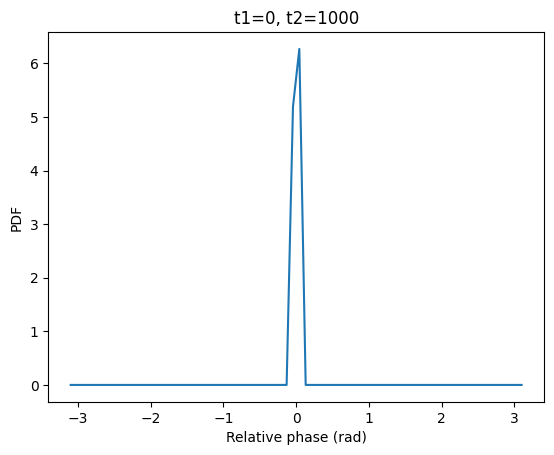

Setting freq=[2.01260491 3.18664119 5.04554173]...[31.71073806 50.20893243 79.49789407], nfreq=9
Setting freq=[2.03840754 3.44021798 5.80605178]...[27.91037917 47.10431367 79.49789407], nfreq=8
Setting freq=[2.01260491 3.18664119 5.04554173]...[31.71073806 50.20893243 79.49789407], nfreq=9
Setting freq=[2.03840754 3.44021798 5.80605178]...[27.91037917 47.10431367 79.49789407], nfreq=8
Setting freq=[2.01260491 3.18664119 5.04554173]...[31.71073806 50.20893243 79.49789407], nfreq=9
Setting freq=[2.03840754 3.44021798 5.80605178]...[27.91037917 47.10431367 79.49789407], nfreq=8
Setting freq=[2.01260491 3.18664119 5.04554173]...[31.71073806 50.20893243 79.49789407], nfreq=9
Setting freq=[2.03840754 3.44021798 5.80605178]...[27.91037917 47.10431367 79.49789407], nfreq=8
Setting freq=[2.01260491 3.18664119 5.04554173]...[31.71073806 50.20893243 79.49789407], nfreq=9
Setting freq=[2.03840754 3.44021798 5.80605178]...[27.91037917 47.10431367 79.49789407], nfreq=8
Setting freq=[2.01260491 3.186

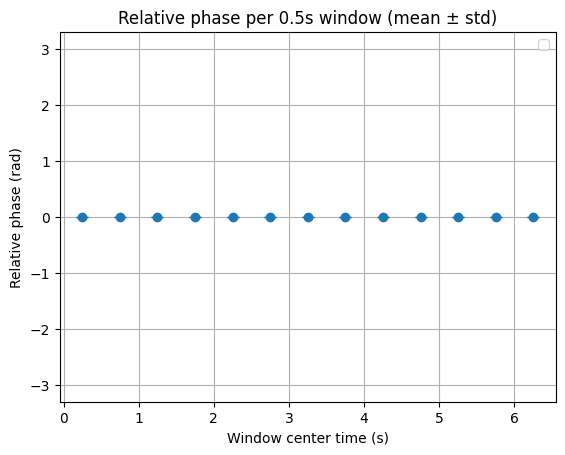

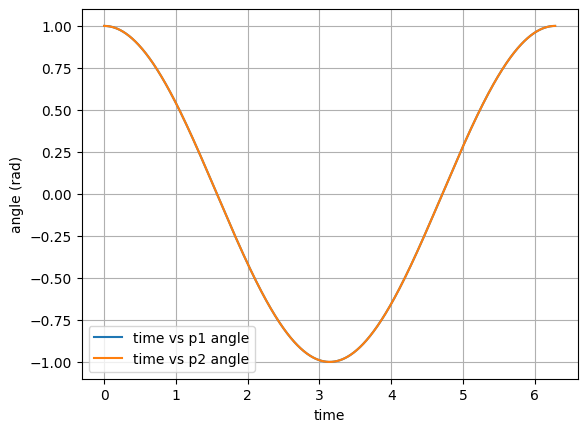

Setting freq=[0.15915494 0.16935791 0.18021496]...[70.20772725 74.70854345 79.49789407], nfreq=101


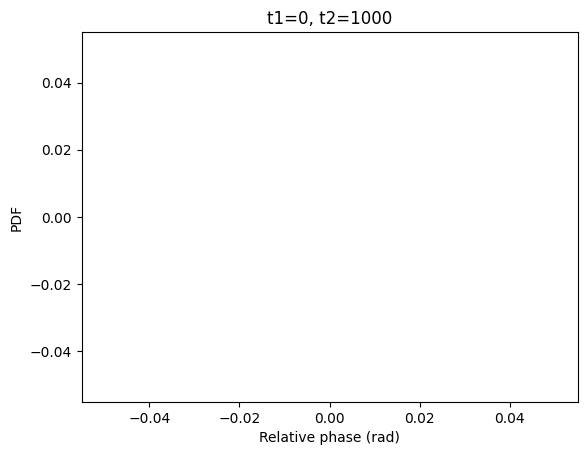

Setting freq=[2.01260491 3.18664119 5.04554173]...[31.71073806 50.20893243 79.49789407], nfreq=9
Setting freq=[2.03840754 3.44021798 5.80605178]...[27.91037917 47.10431367 79.49789407], nfreq=8
Setting freq=[2.01260491 3.18664119 5.04554173]...[31.71073806 50.20893243 79.49789407], nfreq=9
Setting freq=[2.03840754 3.44021798 5.80605178]...[27.91037917 47.10431367 79.49789407], nfreq=8
Setting freq=[2.01260491 3.18664119 5.04554173]...[31.71073806 50.20893243 79.49789407], nfreq=9
Setting freq=[2.03840754 3.44021798 5.80605178]...[27.91037917 47.10431367 79.49789407], nfreq=8
Setting freq=[2.01260491 3.18664119 5.04554173]...[31.71073806 50.20893243 79.49789407], nfreq=9
Setting freq=[2.03840754 3.44021798 5.80605178]...[27.91037917 47.10431367 79.49789407], nfreq=8
Setting freq=[2.01260491 3.18664119 5.04554173]...[31.71073806 50.20893243 79.49789407], nfreq=9
Setting freq=[2.03840754 3.44021798 5.80605178]...[27.91037917 47.10431367 79.49789407], nfreq=8
Setting freq=[2.01260491 3.186

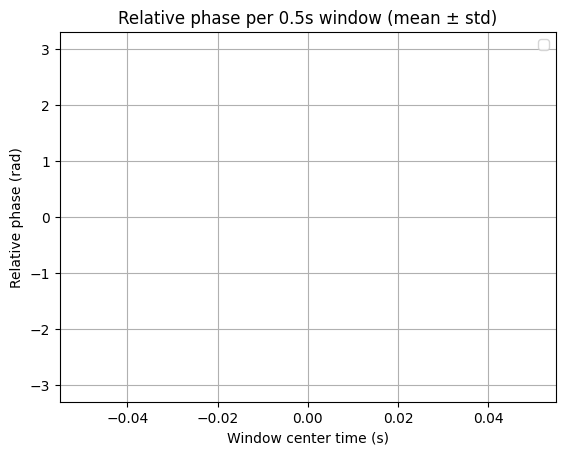

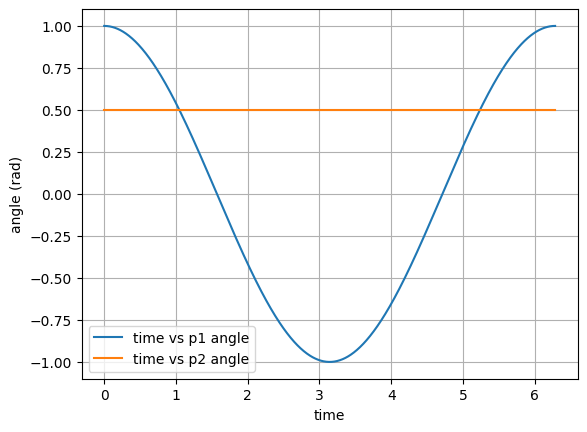

In [18]:
# Example:
centers, pdf, phi_t, window_stats = analyze_relative_phase_windowed(
    y, z, x, start_time=0, end_time=len(x), window_size=0.5
)
centers, pdf, phi_t, window_stats = analyze_relative_phase_windowed(
    y, y, x, start_time=0, end_time=len(x), window_size=0.5
)
centers, pdf, phi_t, window_stats = analyze_relative_phase_windowed(
    y, c_sig, x, start_time=0, end_time=len(x), window_size=0.5
)

Setting freq=[0.35727045 0.36663398 0.37624292]...[474.78694552 487.23041035 500.00000001], nfreq=281


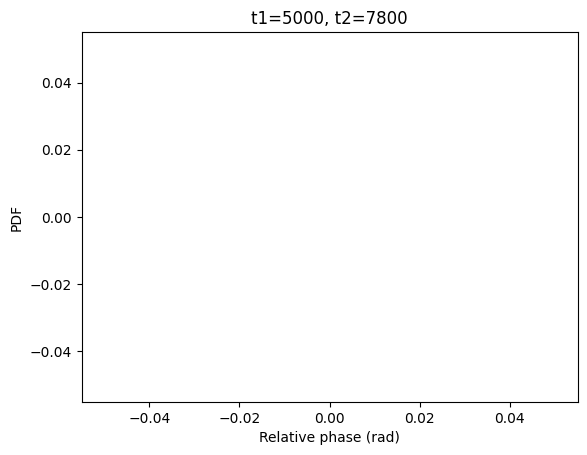

Setting freq=[20.         38.07307878 72.47796637]...[137.97296615 262.65278045 500.00000001], nfreq=6
Setting freq=[20.40816327 38.69342173 73.36186337]...[139.09245438 263.71618682 500.00000001], nfreq=6
Setting freq=[20.40816327 38.69342173 73.36186337]...[139.09245438 263.71618682 500.00000001], nfreq=6
Setting freq=[20.40816327 38.69342173 73.36186337]...[139.09245438 263.71618682 500.00000001], nfreq=6
Setting freq=[20.40816327 38.69342173 73.36186337]...[139.09245438 263.71618682 500.00000001], nfreq=6
Setting freq=[20.40816327 38.69342173 73.36186337]...[139.09245438 263.71618682 500.00000001], nfreq=6
Setting freq=[20.40816327 38.69342173 73.36186337]...[139.09245438 263.71618682 500.00000001], nfreq=6
Setting freq=[20.40816327 38.69342173 73.36186337]...[139.09245438 263.71618682 500.00000001], nfreq=6
Setting freq=[20.40816327 38.69342173 73.36186337]...[139.09245438 263.71618682 500.00000001], nfreq=6
Setting freq=[20.40816327 38.69342173 73.36186337]...[139.09245438 263.71

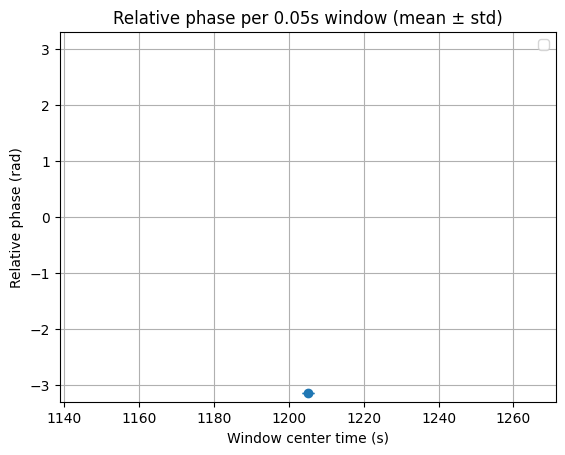

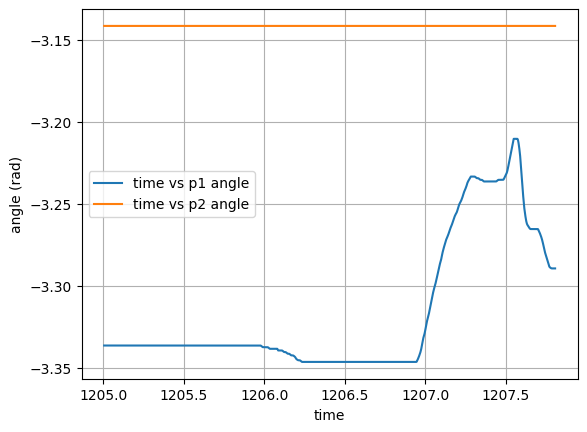

Setting freq=[0.50025013 0.5178287  0.53602499]...[466.62948413 483.02664737 500.00000001], nfreq=201


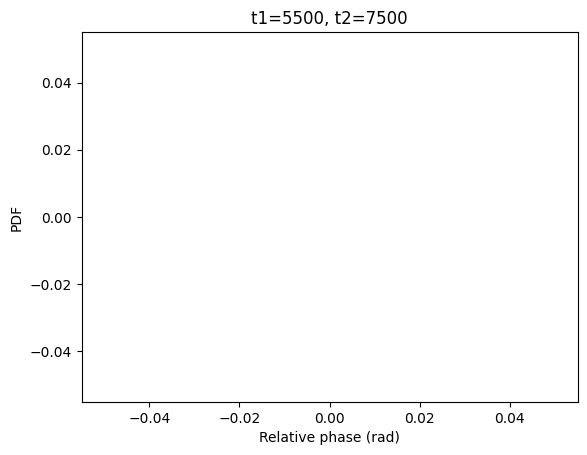

Setting freq=[5.         6.29462706 7.92446596]...[315.47867225 397.16411737 500.00000001], nfreq=21
Setting freq=[ 6.32467302  7.96029627 10.01890793]...[315.63684689 397.26366993 500.00000001], nfreq=20
Setting freq=[ 6.32467302  7.96029627 10.01890793]...[315.63684689 397.26366993 500.00000001], nfreq=20
Setting freq=[ 6.32467302  7.96029627 10.01890793]...[315.63684689 397.26366993 500.00000001], nfreq=20
Setting freq=[ 6.32467302  7.96029627 10.01890793]...[315.63684689 397.26366993 500.00000001], nfreq=20
Setting freq=[ 6.32467302  7.96029627 10.01890793]...[315.63684689 397.26366993 500.00000001], nfreq=20
Setting freq=[ 6.32467302  7.96029627 10.01890793]...[315.63684689 397.26366993 500.00000001], nfreq=20
Setting freq=[ 6.32467302  7.96029627 10.01890793]...[315.63684689 397.26366993 500.00000001], nfreq=20
Setting freq=[ 6.32467302  7.96029627 10.01890793]...[315.63684689 397.26366993 500.00000001], nfreq=20
Setting freq=[ 6.43232887  8.19222124 10.43362212]...[308.25004009 

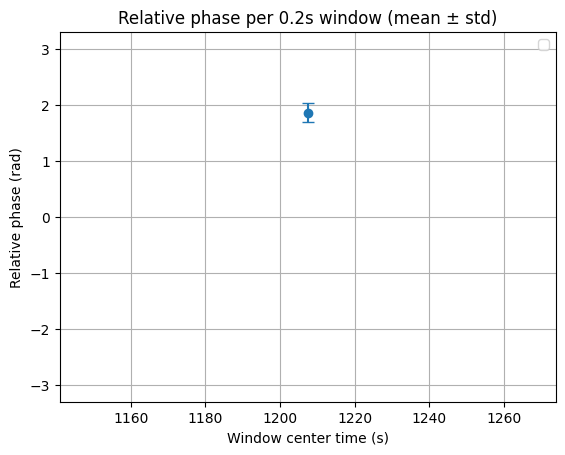

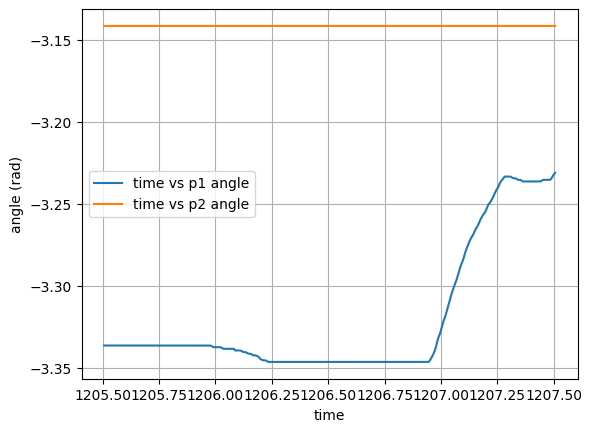

In [19]:
centers, pdf, phi_t, window_stats = analyze_relative_phase_windowed(
    theta1, theta2, t_rs, start_time=5000, end_time=7800, window_size=0.05
)
centers, pdf, phi_t, window_stats = analyze_relative_phase_windowed(
    theta1, theta2, t_rs, start_time=5500, end_time=7500, window_size=0.2
)


Setting freq=[0.62539087 0.6520699  0.67988705]...[459.92262407 479.54281565 500.00000001], nfreq=161


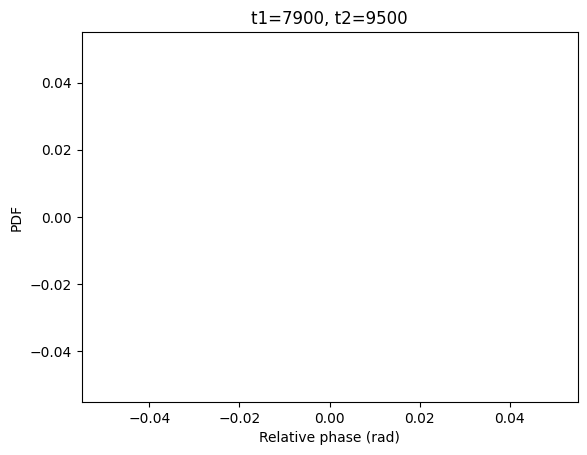

Setting freq=[2.         2.2335146  2.49429374]...[400.915091   447.72485468 500.00000001], nfreq=51
Setting freq=[2.00400802 2.23790097 2.49909218]...[400.9471976  447.74278197 500.00000001], nfreq=51
Setting freq=[2.00400802 2.23790097 2.49909218]...[400.9471976  447.74278197 500.00000001], nfreq=51
Setting freq=[10.20408163 15.72437849 24.23109572]...[210.55757756 324.46693018 500.00000001], nfreq=10


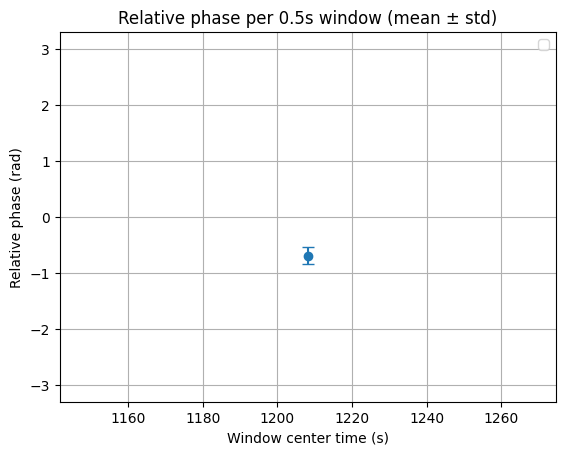

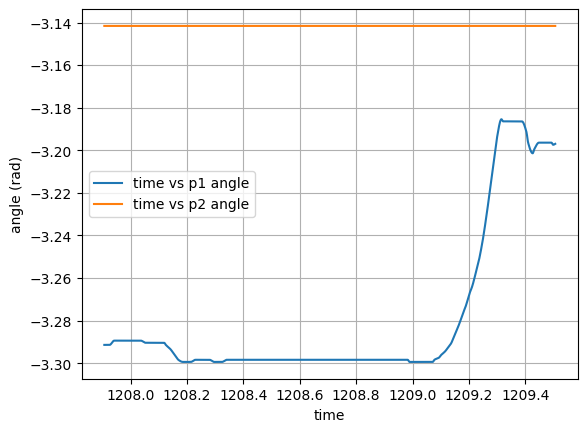

Setting freq=[1.001001   1.06517231 1.13345745]...[441.56973003 469.87750001 500.00000001], nfreq=101


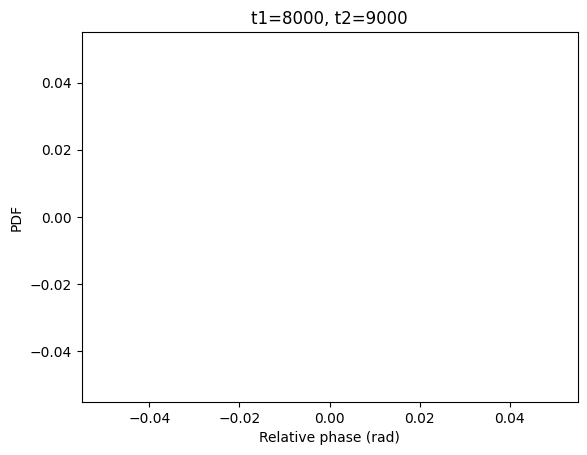

Setting freq=[100.         500.00000001]...[100.         500.00000001], nfreq=2


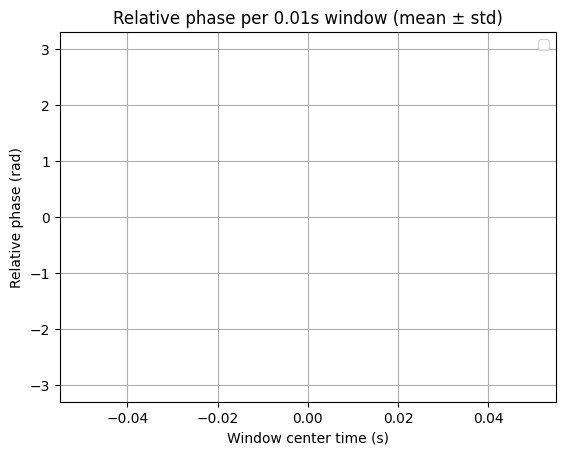

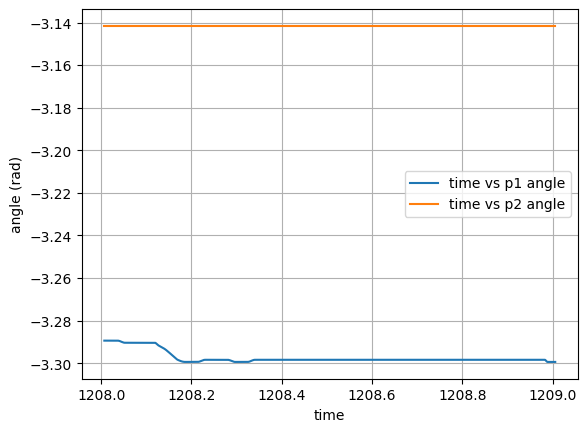

In [20]:
centers, pdf, phi_t, window_stats = analyze_relative_phase_windowed(
    theta1, theta2, t_rs, start_time=7900, end_time=9500, window_size=0.5
)

centers, pdf, phi_t, window_stats = analyze_relative_phase_windowed(
    theta1, theta2, t_rs, start_time=8000, end_time=9000, window_size=0.01
)

Setting freq=[0.43497173 0.44850531 0.46245997]...[470.28040422 484.91257162 500.00000001], nfreq=231


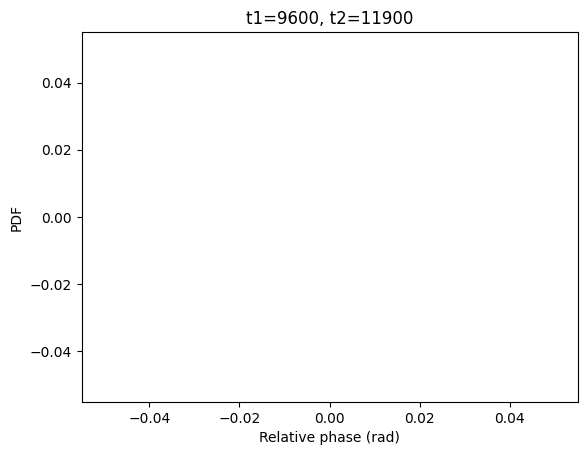

Setting freq=[10.         14.78757637 21.86724148]...[228.65252597 338.12166891 500.00000001], nfreq=11
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.112595

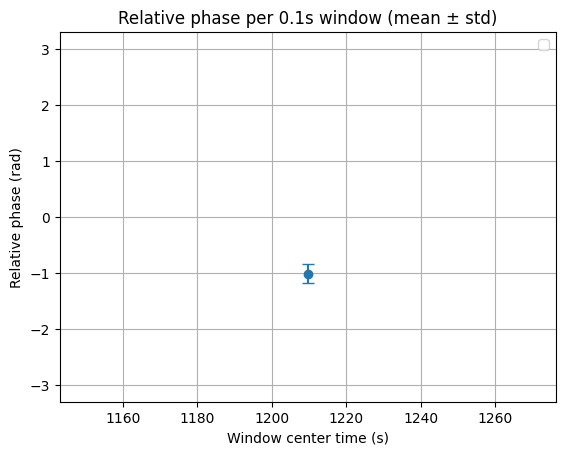

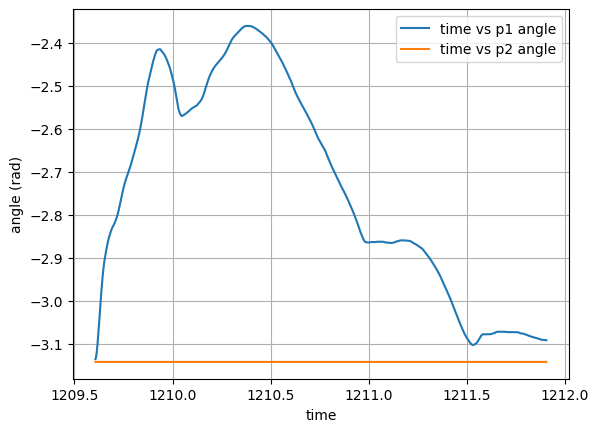

Setting freq=[1.001001   1.06517231 1.13345745]...[441.56973003 469.87750001 500.00000001], nfreq=101


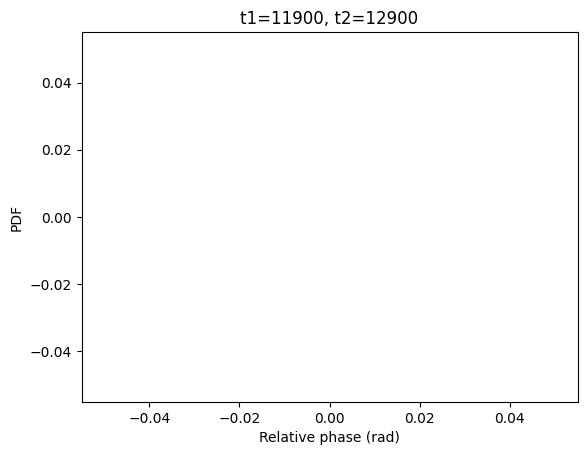

Setting freq=[10.         14.78757637 21.86724148]...[228.65252597 338.12166891 500.00000001], nfreq=11
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[10.20408163 15.72437849 24.23109572]...[210.557577

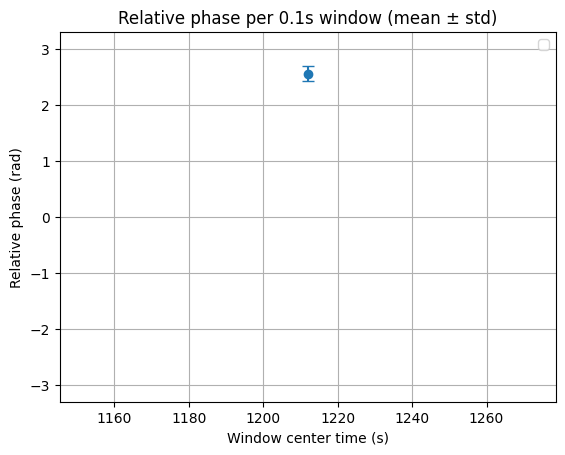

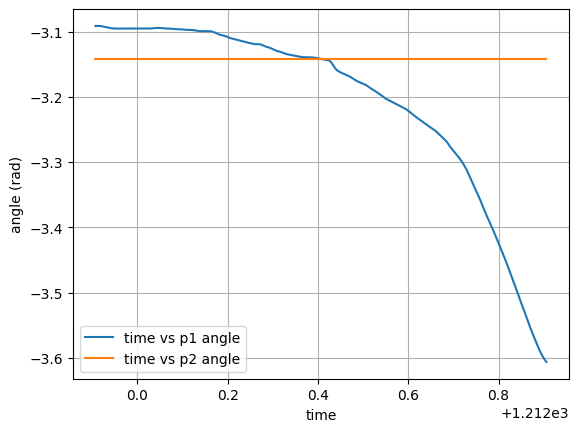

In [21]:
centers, pdf, phi_t, window_stats = analyze_relative_phase_windowed(
    theta1, theta2, t_rs, start_time=9600, end_time=11900, window_size=0.1
)

centers, pdf, phi_t, window_stats = analyze_relative_phase_windowed(
    theta1, theta2, t_rs, start_time=11900, end_time=12900, window_size=0.1
)

Setting freq=[3.95199923 4.66987108 5.51814275]...[358.09142788 423.13793725 500.00000001], nfreq=30


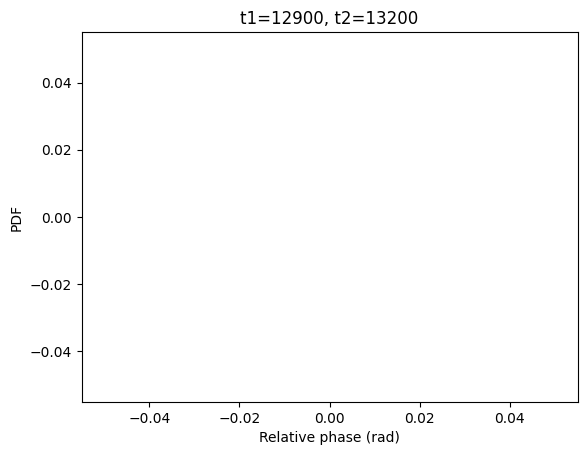

Setting freq=[100.         500.00000001]...[100.         500.00000001], nfreq=2


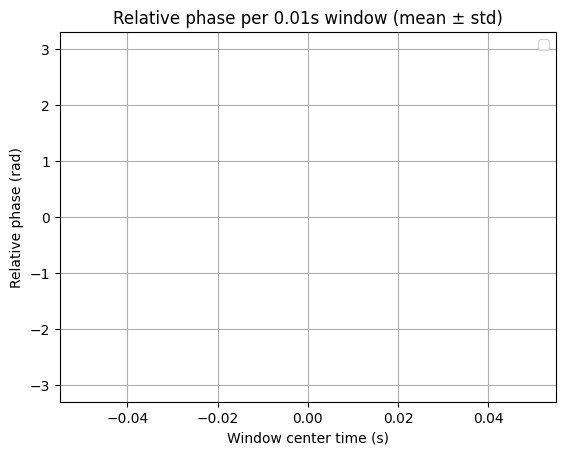

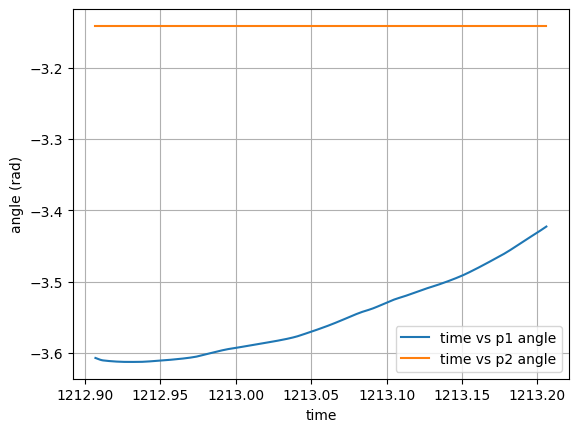

Setting freq=[1.43061516 1.55545619 1.69119133]...[422.96076697 459.86996367 500.00000001], nfreq=71


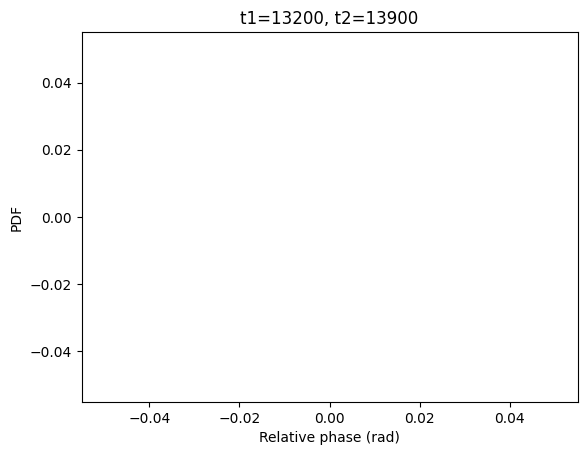

Setting freq=[100.         500.00000001]...[100.         500.00000001], nfreq=2


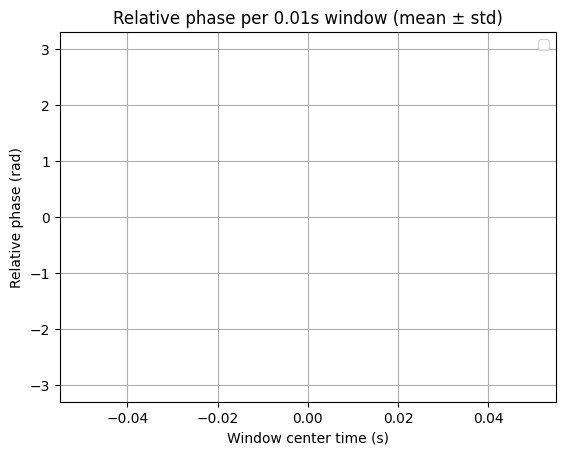

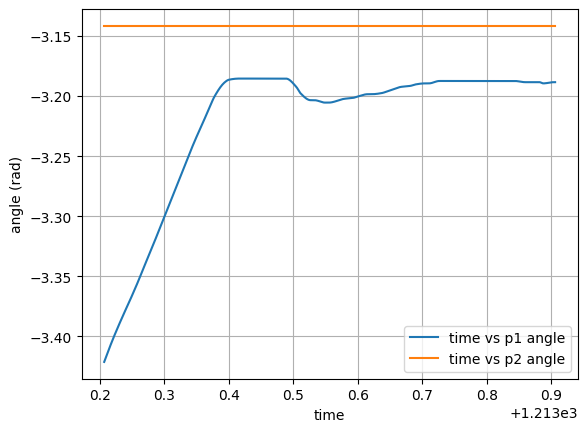

In [22]:
centers, pdf, phi_t, window_stats = analyze_relative_phase_windowed(
    theta1, theta2, t_rs, start_time=12900, end_time=13200, window_size=0.01
)

centers, pdf, phi_t, window_stats = analyze_relative_phase_windowed(
    theta1, theta2, t_rs, start_time=13200, end_time=13900, window_size=0.01
)

Setting freq=[3.95199923 4.66987108 5.51814275]...[358.09142788 423.13793725 500.00000001], nfreq=30


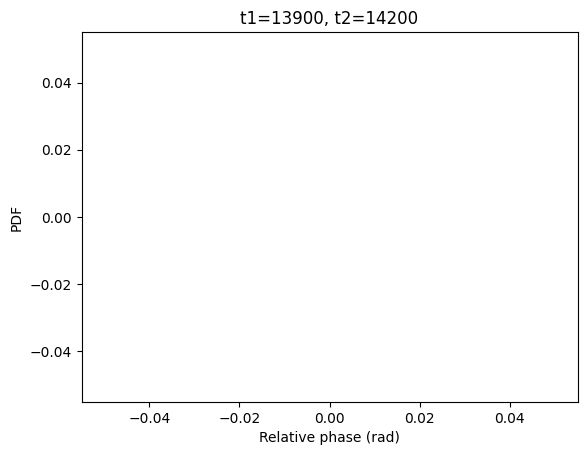

Setting freq=[100.         500.00000001]...[100.         500.00000001], nfreq=2


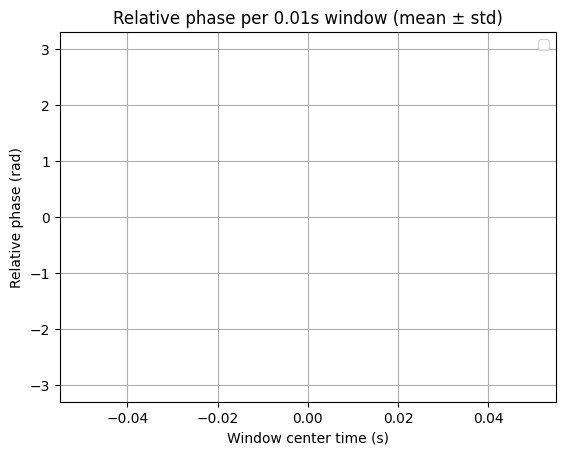

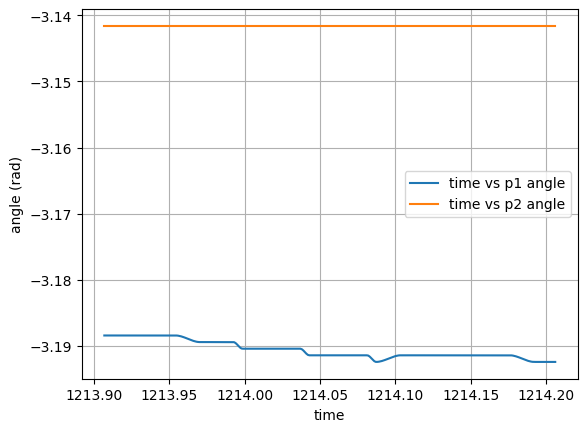

Setting freq=[1.11234705 1.19046075 1.27405993]...[436.5363929  467.19181976 500.00000001], nfreq=91


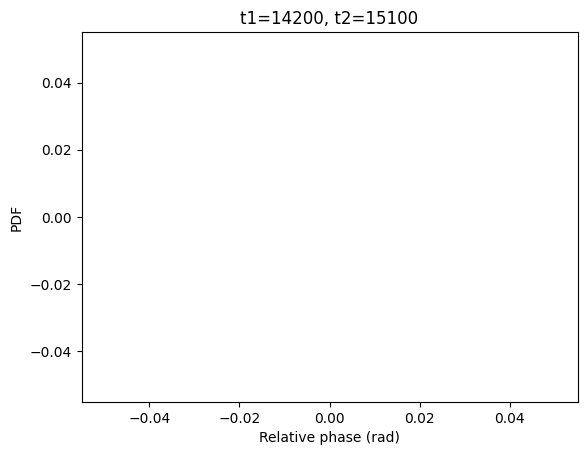

Setting freq=[10.         14.78757637 21.86724148]...[228.65252597 338.12166891 500.00000001], nfreq=11
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[10.20408163 15.72437849 24.23109572]...[210.55757756 324.46693018 500.00000001], nfreq=10


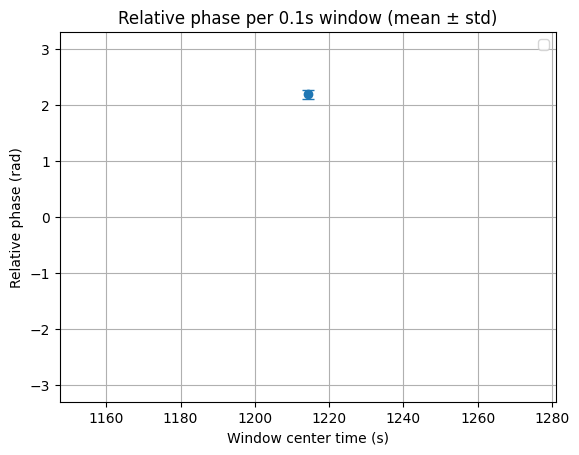

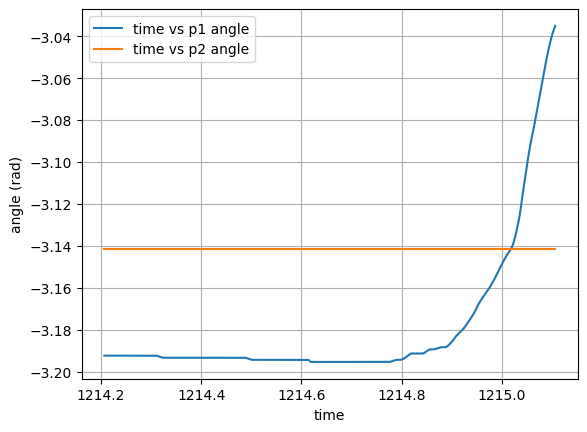

In [23]:
centers, pdf, phi_t, window_stats = analyze_relative_phase_windowed(
    theta1, theta2, t_rs, start_time=13900, end_time=14200, window_size=0.01
)

centers, pdf, phi_t, window_stats = analyze_relative_phase_windowed(
    theta1, theta2, t_rs, start_time=14200, end_time=15100, window_size=0.1
)

Setting freq=[0.71479628 0.74903515 0.78491406]...[455.33410411 477.14468672 500.00000001], nfreq=141


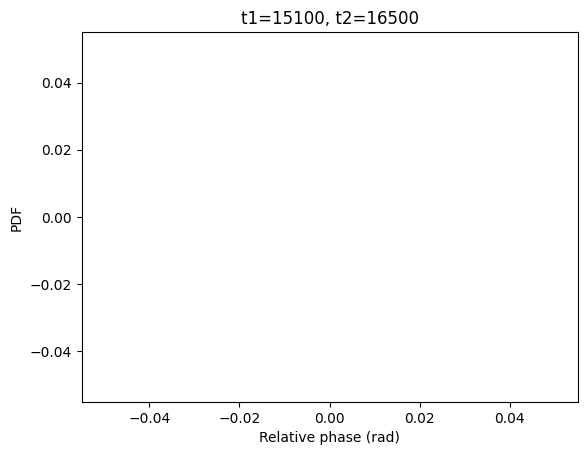

Setting freq=[100.         500.00000001]...[100.         500.00000001], nfreq=2


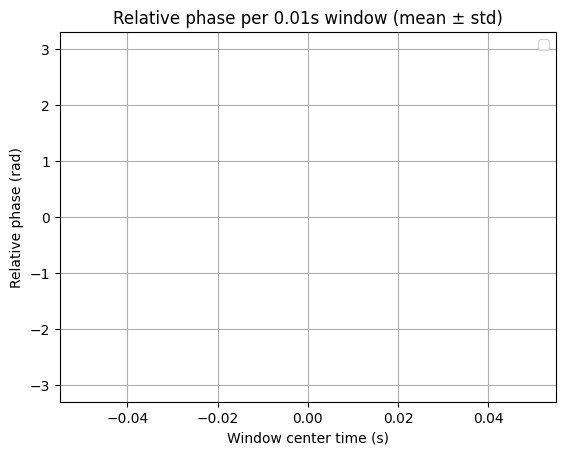

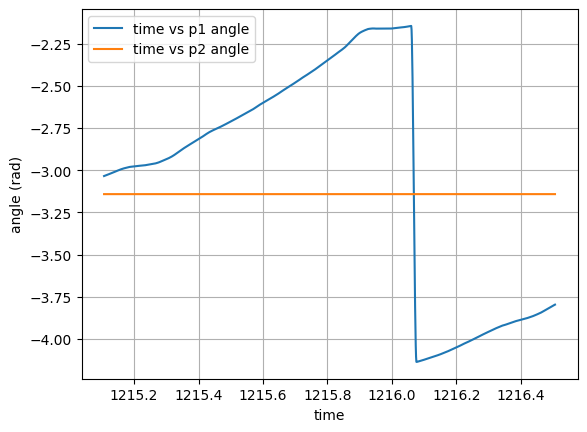

Setting freq=[3.95199923 4.66987108 5.51814275]...[358.09142788 423.13793725 500.00000001], nfreq=30


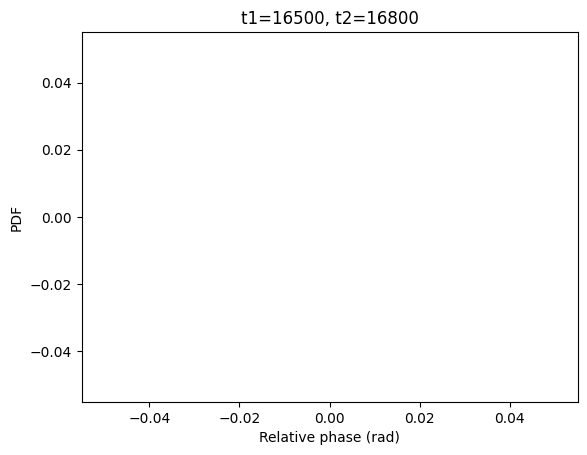

Setting freq=[10.         14.78757637 21.86724148]...[228.65252597 338.12166891 500.00000001], nfreq=11
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[10.20408163 15.72437849 24.23109572]...[210.55757756 324.46693018 500.00000001], nfreq=10


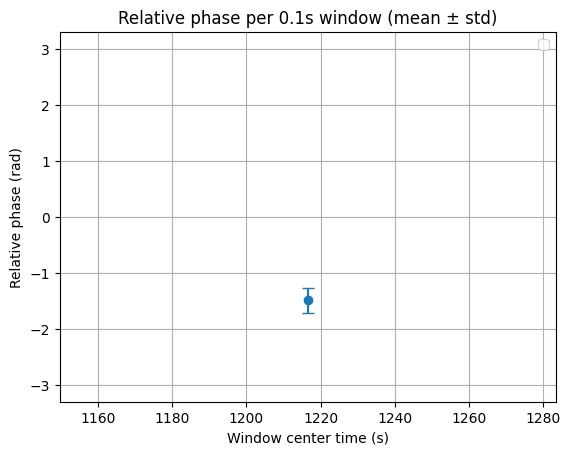

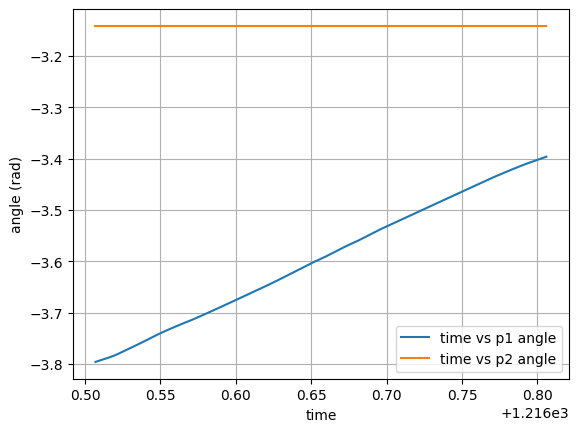

Setting freq=[1.43061516 1.55545619 1.69119133]...[422.96076697 459.86996367 500.00000001], nfreq=71


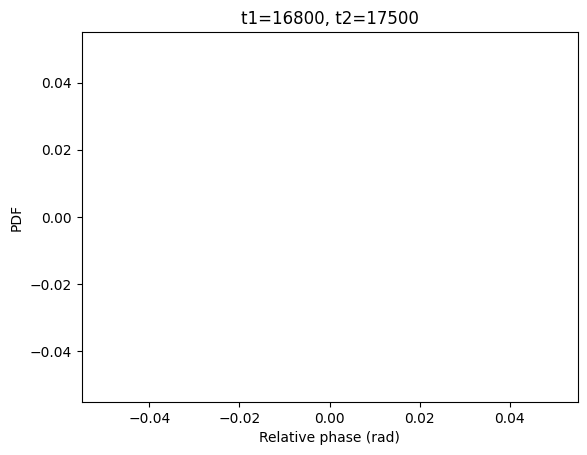

Setting freq=[10.         14.78757637 21.86724148]...[228.65252597 338.12166891 500.00000001], nfreq=11
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[10.20408163 15.72437849 24.23109572]...[210.55757756 324.46693018 500.00000001], nfreq=10


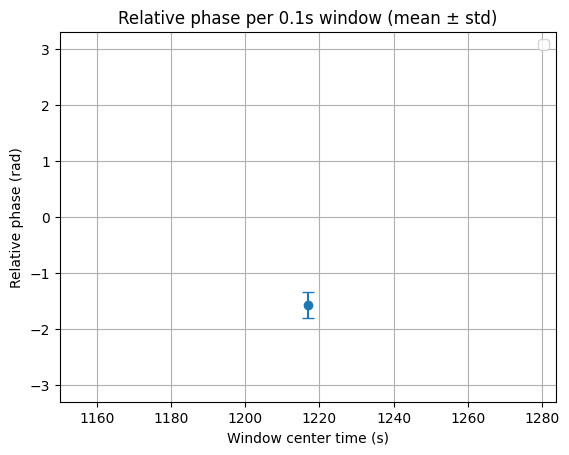

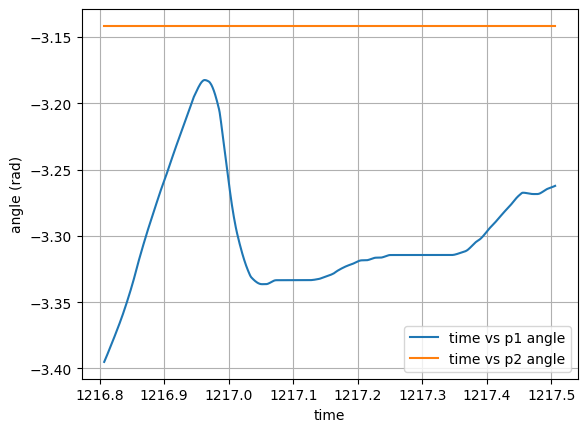

In [24]:
centers, pdf, phi_t, window_stats = analyze_relative_phase_windowed(
    theta1, theta2, t_rs, start_time=15100, end_time=16500, window_size=0.01
)

centers, pdf, phi_t, window_stats = analyze_relative_phase_windowed(
    theta1, theta2, t_rs, start_time=16500, end_time=16800, window_size=0.1
)
centers, pdf, phi_t, window_stats = analyze_relative_phase_windowed(
    theta1, theta2, t_rs, start_time=16800, end_time=17500, window_size=0.1
)

Setting freq=[0.28579594 0.29195877 0.29825449]...[479.11422739 489.44572089 500.00000001], nfreq=351


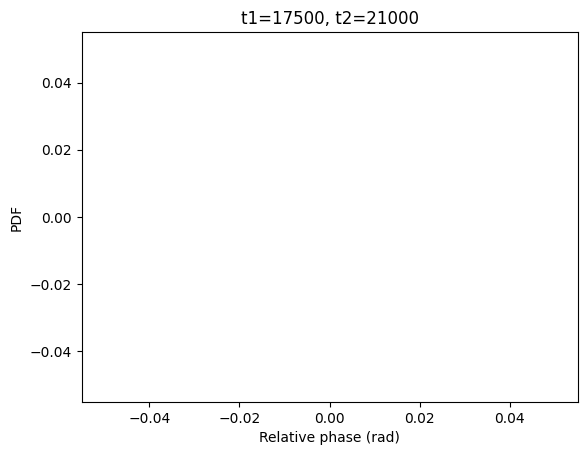

Setting freq=[10.         14.78757637 21.86724148]...[228.65252597 338.12166891 500.00000001], nfreq=11
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.112595

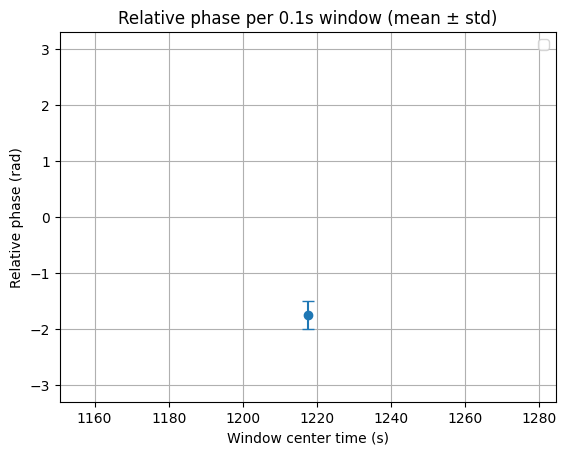

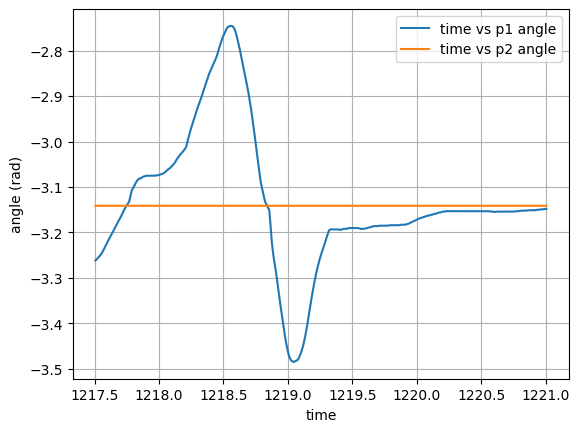

Setting freq=[0.76982294 0.80914448 0.8504745 ]...[452.58437446 475.70178393 500.00000001], nfreq=131


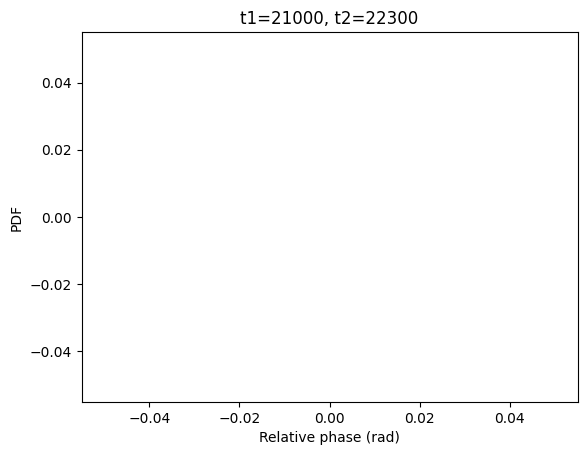

Setting freq=[10.         14.78757637 21.86724148]...[228.65252597 338.12166891 500.00000001], nfreq=11
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.112595

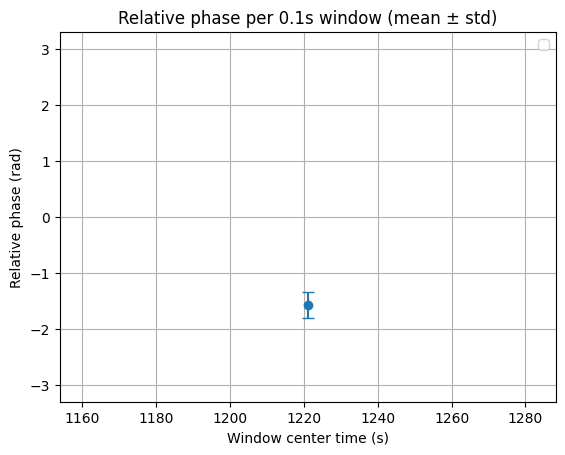

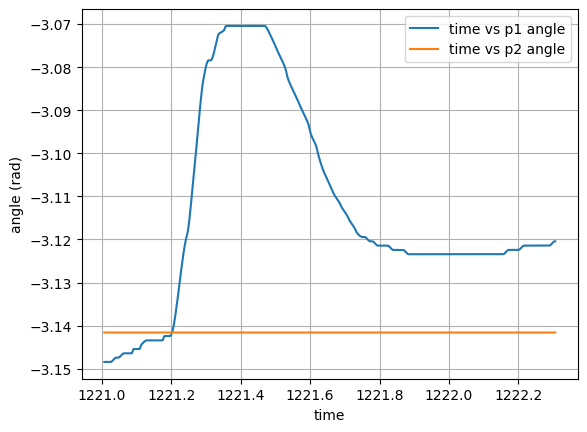

In [25]:
centers, pdf, phi_t, window_stats = analyze_relative_phase_windowed(
    theta1, theta2, t_rs, start_time=17500, end_time=21000, window_size=0.1
)
centers, pdf, phi_t, window_stats = analyze_relative_phase_windowed(
    theta1, theta2, t_rs, start_time=21000, end_time=22300, window_size=0.1
)

Setting freq=[1.11234705 1.19046075 1.27405993]...[436.5363929  467.19181976 500.00000001], nfreq=91


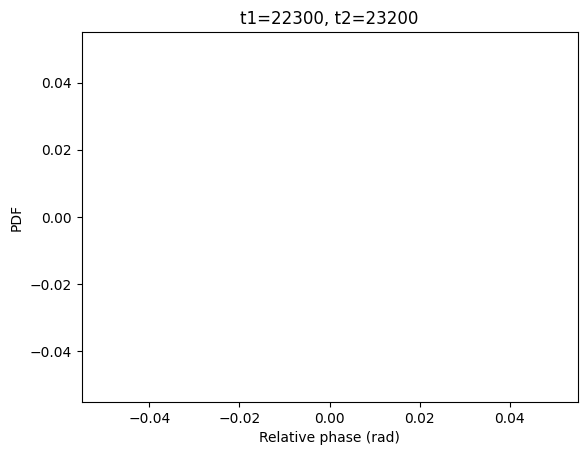

Setting freq=[10.         14.78757637 21.86724148]...[228.65252597 338.12166891 500.00000001], nfreq=11
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[10.20408163 15.72437849 24.23109572]...[210.55757756 324.46693018 500.00000001], nfreq=10


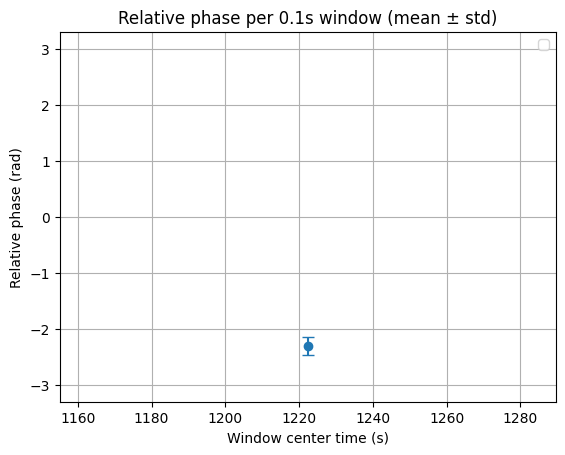

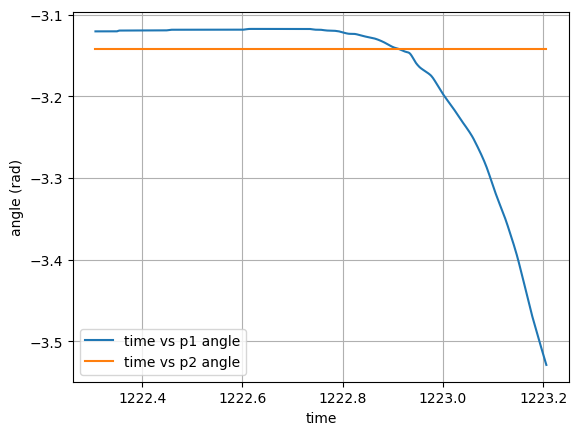

Setting freq=[0.83402836 0.87968879 0.927849  ]...[449.44185867 474.04739145 500.00000001], nfreq=121


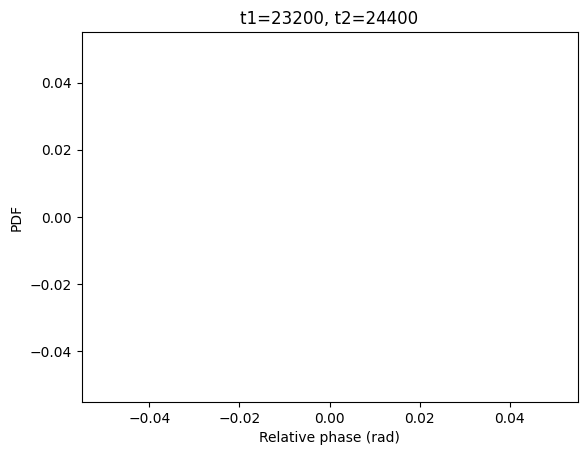

Setting freq=[10.         14.78757637 21.86724148]...[228.65252597 338.12166891 500.00000001], nfreq=11
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.112595

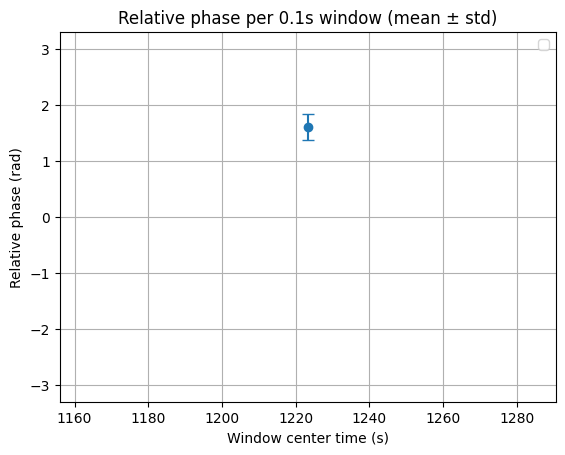

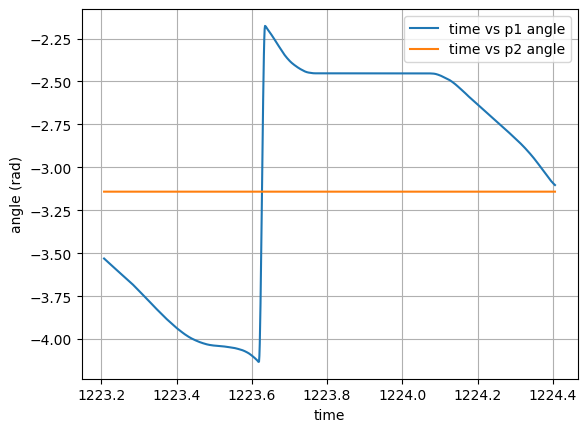

Setting freq=[1.001001   1.06517231 1.13345745]...[441.56973003 469.87750001 500.00000001], nfreq=101


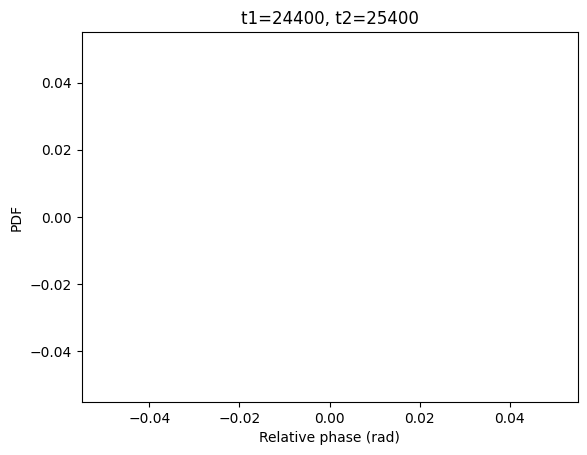

Setting freq=[10.         14.78757637 21.86724148]...[228.65252597 338.12166891 500.00000001], nfreq=11
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[14.92194123 22.04376869 32.56464627]...[229.11259514 338.46166337 500.00000001], nfreq=10
Setting freq=[10.20408163 15.72437849 24.23109572]...[210.557577

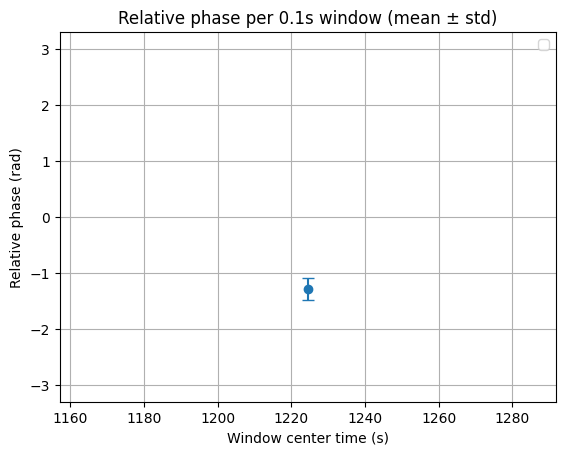

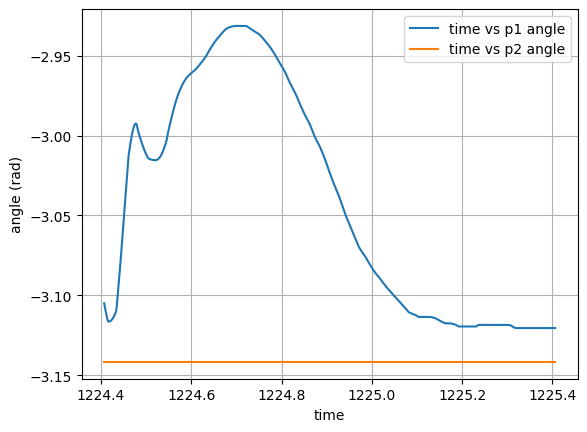

In [26]:
centers, pdf, phi_t, window_stats = analyze_relative_phase_windowed(
    theta1, theta2, t_rs, start_time=22300, end_time=23200, window_size=0.1
)
centers, pdf, phi_t, window_stats = analyze_relative_phase_windowed(
    theta1, theta2, t_rs, start_time=23200, end_time=24400, window_size=0.1
)
centers, pdf, phi_t, window_stats = analyze_relative_phase_windowed(
    theta1, theta2, t_rs, start_time=24400, end_time=25400, window_size=0.1
)

Setting freq=[0.27785496 0.28370059 0.28966921]...[479.60734706 489.6975327  500.00000001], nfreq=361


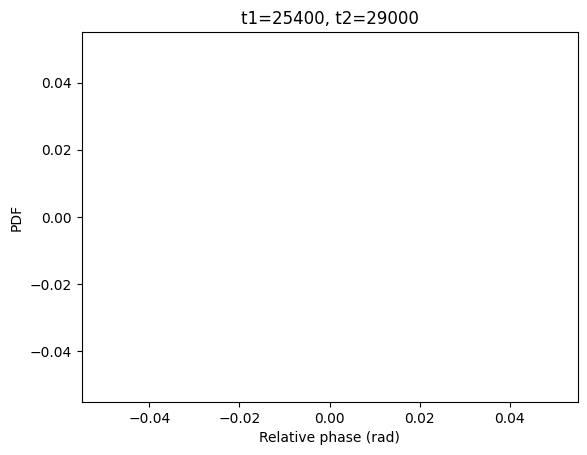

Setting freq=[5.         6.29462706 7.92446596]...[315.47867225 397.16411737 500.00000001], nfreq=21
Setting freq=[ 6.32467302  7.96029627 10.01890793]...[315.63684689 397.26366993 500.00000001], nfreq=20
Setting freq=[ 6.32467302  7.96029627 10.01890793]...[315.63684689 397.26366993 500.00000001], nfreq=20
Setting freq=[ 6.32467302  7.96029627 10.01890793]...[315.63684689 397.26366993 500.00000001], nfreq=20
Setting freq=[ 6.32467302  7.96029627 10.01890793]...[315.63684689 397.26366993 500.00000001], nfreq=20
Setting freq=[ 6.32467302  7.96029627 10.01890793]...[315.63684689 397.26366993 500.00000001], nfreq=20
Setting freq=[ 6.32467302  7.96029627 10.01890793]...[315.63684689 397.26366993 500.00000001], nfreq=20
Setting freq=[ 6.32467302  7.96029627 10.01890793]...[315.63684689 397.26366993 500.00000001], nfreq=20
Setting freq=[ 6.32467302  7.96029627 10.01890793]...[315.63684689 397.26366993 500.00000001], nfreq=20
Setting freq=[ 6.32467302  7.96029627 10.01890793]...[315.63684689 

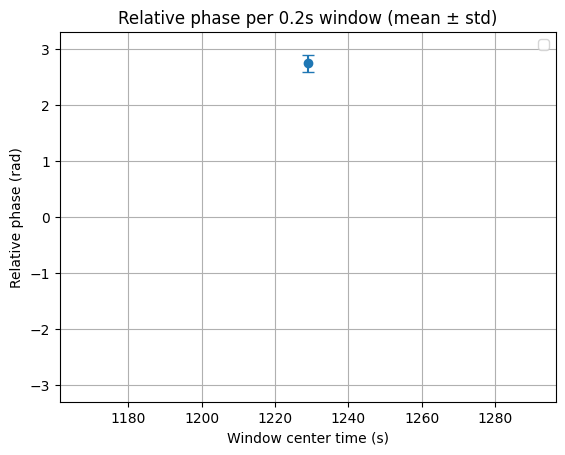

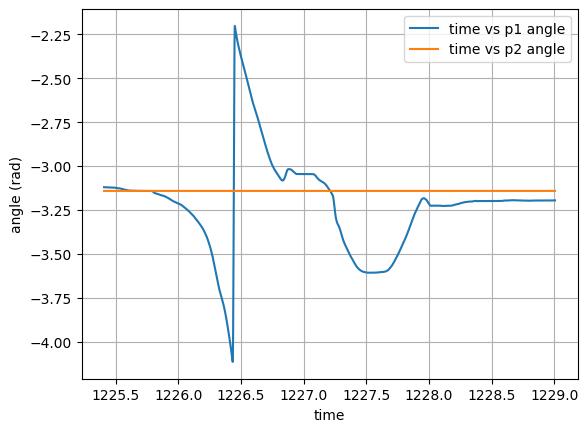

Setting freq=[1.001001   1.06517231 1.13345745]...[441.56973003 469.87750001 500.00000001], nfreq=101


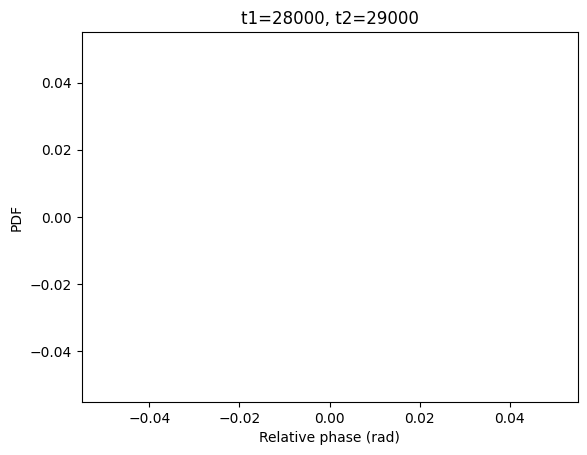

Setting freq=[5.         6.29462706 7.92446596]...[315.47867225 397.16411737 500.00000001], nfreq=21
Setting freq=[ 6.32467302  7.96029627 10.01890793]...[315.63684689 397.26366993 500.00000001], nfreq=20
Setting freq=[ 6.32467302  7.96029627 10.01890793]...[315.63684689 397.26366993 500.00000001], nfreq=20
Setting freq=[ 6.32467302  7.96029627 10.01890793]...[315.63684689 397.26366993 500.00000001], nfreq=20
Setting freq=[ 6.43232887  8.19222124 10.43362212]...[308.25004009 392.58759539 500.00000001], nfreq=19


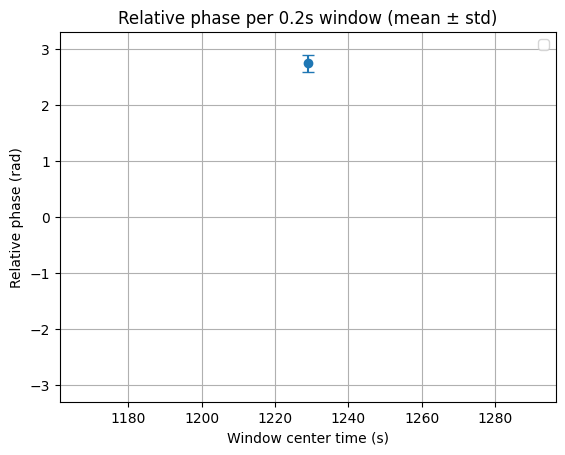

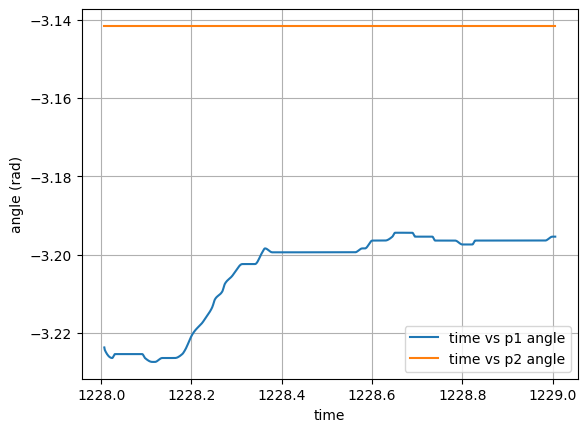

In [27]:
centers, pdf, phi_t, window_stats = analyze_relative_phase_windowed(
    theta1, theta2, t_rs, start_time=25400, end_time=29000, window_size=0.2
)
centers, pdf, phi_t, window_stats = analyze_relative_phase_windowed(
    theta1, theta2, t_rs, start_time=28000, end_time=29000, window_size=0.2
)

In [28]:
def analyze_relative_phase_windowed_2(theta1, theta2, t_rs, start_time, end_time, window_size=0.1):
    """
    Slice [start_time : start_time+step] from signals, compute relative phase PDF,
    then compute windowed mean/std of phase vs time and plot both.

    Returns:
        centers, pdf, phi_t, window_stats
    """
    # indices
    t1 = int(start_time)
    t2 = int(end_time)

    # clip to array bounds
    n = min(len(theta1), len(theta2), len(t_rs))
    t1 = max(0, min(t1, n))
    t2 = max(t1, min(t2, n))

    # slice
    p1 = theta1[t1:t2]
    p2 = theta2[t1:t2]
    t  = t_rs[t1:t2]

    # compute phase + PDF
    #centers, pdf, phi_t = relative_phase_dis(p1, p2, t)

    # plt.figure()
    # plt.plot(centers, pdf)
    # plt.xlabel("Relative phase (rad)")
    # plt.ylabel("PDF")
    # plt.title(f"t1={t1}, t2={t2}")
    # plt.show()

    # window stats
    window_stats = split_phase_into_windows(p1, p2, t, window_size=window_size)
    # for w in window_stats:
        # print(
        #     f"Window {w['start']}–{w['end']} s: "
        #     f"mean phase={w['mean_phase']:.2f} rad, "
        #     f"std={w['std_phase']:.2f} rad"
        # )

    centers_t = np.array([w["center_time"] for w in window_stats])
    means     = np.array([w["mean_phase"]  for w in window_stats])
    stds      = np.array([w["std_phase"]   for w in window_stats])

    plt.figure()
    plt.errorbar(centers_t, means, yerr=stds, fmt="o", capsize=4)
    plt.xlabel("Window center time (s)")
    plt.ylim(-np.pi*1.05, np.pi*1.05)
    plt.ylabel("Relative phase (rad)")
    plt.title(f"Relative phase per {window_size}s window (mean ± std)")
    plt.legend()
    plt.grid(True)
    plt.show()
    
    plot_cos_angles_by_index(t_rs, theta1, theta2, t1, t2)
    return centers, pdf, phi_t, window_stats


# Example:
# centers, pdf, phi_t, window_stats = analyze_relative_phase_windowed(
#     theta1, theta2, t_rs, start_time=8000, step=1000, window_size=0.1
# )

Setting freq=[5.         6.29462706 7.92446596]...[315.47867225 397.16411737 500.00000001], nfreq=21
Setting freq=[ 6.32467302  7.96029627 10.01890793]...[315.63684689 397.26366993 500.00000001], nfreq=20
Setting freq=[ 6.32467302  7.96029627 10.01890793]...[315.63684689 397.26366993 500.00000001], nfreq=20
Setting freq=[ 6.32467302  7.96029627 10.01890793]...[315.63684689 397.26366993 500.00000001], nfreq=20
Setting freq=[ 6.32467302  7.96029627 10.01890793]...[315.63684689 397.26366993 500.00000001], nfreq=20
Setting freq=[ 6.32467302  7.96029627 10.01890793]...[315.63684689 397.26366993 500.00000001], nfreq=20
Setting freq=[ 6.32467302  7.96029627 10.01890793]...[315.63684689 397.26366993 500.00000001], nfreq=20
Setting freq=[ 6.32467302  7.96029627 10.01890793]...[315.63684689 397.26366993 500.00000001], nfreq=20
Setting freq=[ 6.32467302  7.96029627 10.01890793]...[315.63684689 397.26366993 500.00000001], nfreq=20
Setting freq=[ 6.32467302  7.96029627 10.01890793]...[315.63684689 

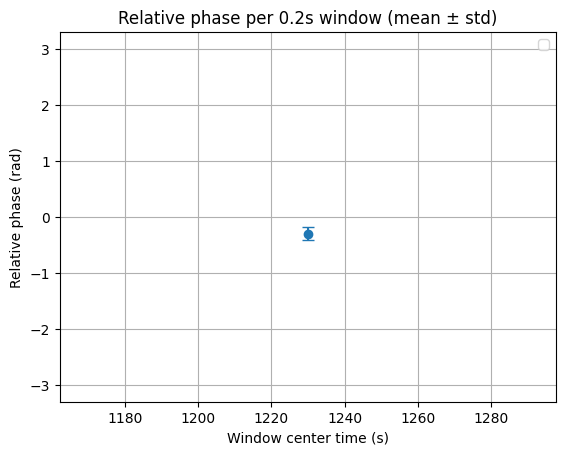

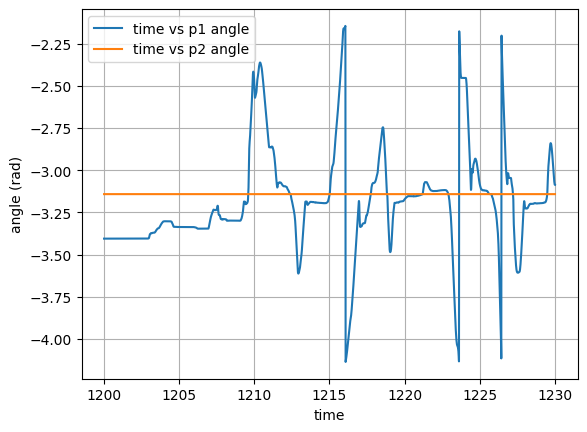

In [29]:
centers, pdf, phi_t, window_stats = analyze_relative_phase_windowed_2(
    theta1, theta2, t_rs, start_time=0, end_time=30000, window_size=0.2
)

In [30]:
# #
# t1 = 8000
# t2 = t1 + 1000

# p1 = theta1[t1:t2]
# p2 = theta2[t1:t2]
# t = t_rs[t1:t2]

# centers, pdf, phi_t = relative_phase_dis(p1, p2, t)
# plt.plot(centers, pdf)
# plt.xlabel("Relative phase (rad)")
# plt.ylabel("PDF")
# plt.show()

# window_size = 0.1
# window_stats = split_phase_into_windows(t, phi_t, window_size=window_size)
# for w in window_stats:
#     print(
#         f"Window {w['start']}–{w['end']} s: "
#         f"mean phase={w['mean_phase']:.2f} rad, "
#         f"std={w['std_phase']:.2f} rad"
#     )
    
# centers_t = np.array([w["center_time"] for w in window_stats])
# means     = np.array([w["mean_phase"]   for w in window_stats])
# stds      = np.array([w["std_phase"]    for w in window_stats])

# plt.figure()
# plt.errorbar(centers_t, means, yerr=stds, fmt='o-', capsize=4)
# plt.xlabel("Window center time (s)")
# plt.ylabel("Relative phase (rad)")
# plt.title(f"Relative phase per {window_size}s window (mean ± std)")
# plt.grid(True)
# plt.show()

In [31]:
# #CALL FUNCTION TO CALCULATE
# centers, pdf, phi_t = relative_phase_dis(theta1, theta2, t_rs)
# plt.plot(centers, pdf)
# plt.xlabel("Relative phase (rad)")
# plt.ylabel("PDF")
# plt.show()


In [32]:
# window_size = 1.0
# window_stats = split_phase_into_windows(t_rs, phi_t, window_size=window_size)
# for w in window_stats:
#     print(
#         f"Window {w['start']}–{w['end']} s: "
#         f"mean phase={w['mean_phase']:.2f} rad, "
#         f"std={w['std_phase']:.2f} rad"
#     )
    
# centers_t = np.array([w["center_time"] for w in window_stats])
# means     = np.array([w["mean_phase"]   for w in window_stats])
# stds      = np.array([w["std_phase"]    for w in window_stats])

# plt.figure()
# plt.errorbar(centers_t, means, yerr=stds, fmt='o-', capsize=4)
# plt.xlabel("Window center time (s)")
# plt.ylabel("Relative phase (rad)")
# plt.title(f"Relative phase per {window_size}s window (mean ± std)")
# plt.grid(True)
# plt.show()

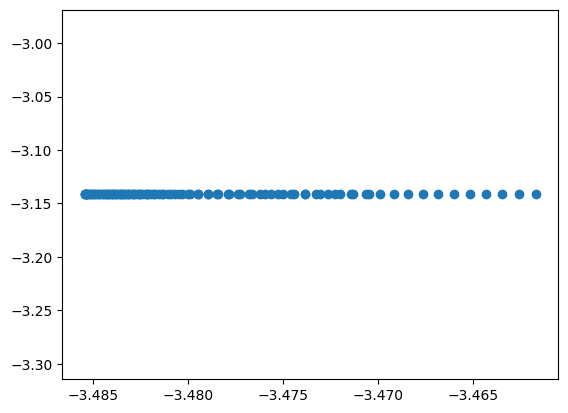

In [33]:
plt.scatter(theta1[19000:19100], theta2[19000:19100])

Correlation
correlation.association
TODO: calculating cross correlation with the window function that is currently avaiable
    #NOTE: 1 number per window, and plot graph vs time.
    - Could prob look at how to visually box the time frames
TODO: Time lag correlation calculation for waves